<a href="https://colab.research.google.com/github/gisele-mgs/fact_checking_br/blob/main/agency_checking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LDA + K-means: central de fatos

# 1. Importar base de dados e bibliotecas

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
%cd /content/gdrive/MyDrive/cp
!ls

/content/gdrive/MyDrive/cp
'=2.0.0'		 lda_document_text.csv		 lda_tittle.csv
 central_de_fatos.csv	 lda_document_topic_tittle.csv	 results
 document_clusters.csv	 lda_text.csv


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import ast
import re
import unicodedata
from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem import RSLPStemmer
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split


In [ ]:
df_original = pd.read_csv( "/content/gdrive/MyDrive/cp/central_de_fatos.csv", decimal=',', header=0, sep=';')
df_original

,url,source_name,title,subtitle,publication_date,text_news,image_link,video_link,authors,categories,tags,obtained_at,rating
0,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Publicações enganam ao associar Bolsonaro à ap...,NaN,2020-07-31,Ancine aprovou em 2019 a captação de 530 mil r...,NaN,NaN,['Projeto Comprova'],['Políticas públicas'],[],2021-07-06,['Enganoso']
1,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Post mostra imagens de outras estradas para af...,NaN,2020-07-31,Parte dos trechos das gravações utilizadas no ...,https://i2.wp.com/projetocomprova.com.br/wp-co...,NaN,['Projeto Comprova'],['Políticas públicas'],[],2021-07-06,['Falso']
2,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Eduardo Bolsonaro posta vídeo antigo sobre lib...,NaN,2020-07-31,"Em uma publicação no Twitter, o deputado usa c...",NaN,NaN,['Projeto Comprova'],['Pandemia'],[],2021-07-06,['Enganoso']
3,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Médica cita estudos não conclusivos para suger...,NaN,2020-07-30,"Procurada pelo Comprova, médica enviou 34 estu...",NaN,NaN,['Projeto Comprova'],['Pandemia'],[],2021-07-06,['Enganoso']
4,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Médica usa informações falsas em vídeo para fa...,NaN,2020-07-29,Ao contrário do que afirma uma médica em vídeo...,NaN,NaN,['Projeto Comprova'],['Pandemia'],[],2021-07-06,['Falso']
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11642,https://piaui.folha.uol.com.br/lupa/2019/09/02...,lupa,#Verificamos: É falso que Cristiano Ronaldo va...,NaN,2019-09-02,Circula nas redes sociais que o jogador de fut...,https://piaui.folha.uol.com.br/lupa/wp-content...,NaN,['NATHÁLIA AFONSO'],[],"['#PRAYFORAMAZONIA', '#VERIFICAMOS', 'AMAZÔNIA...",2021-05-14,['FALSO']
11643,https://piaui.folha.uol.com.br/lupa/2019/09/02...,lupa,#Verificamos: É falso que Funai ‘reestruturada...,NaN,2019-09-02,Circula nas redes sociais que a Fundação Nacio...,https://piaui.folha.uol.com.br/lupa/wp-content...,NaN,['NATHÁLIA AFONSO'],[],"['BOLSONARO', 'CONTRATOS', 'DESINFORMAÇÃO', 'F...",2021-05-14,['FALSO']
11644,https://piaui.folha.uol.com.br/lupa/2019/09/02...,lupa,"Um ano após incêndio, promessas para o Museu N...",NaN,2019-09-02,"Há um ano, um incêndio destruiu o Museu Nacion...",https://piaui.folha.uol.com.br/lupa/wp-content...,NaN,['NATHÁLIA AFONSO'],[],"['BNDES', 'GOVERNO MICHEL TEMER', 'INCÊNDIO', ...",2021-05-14,"['FALSO', 'VERDADEIRO, MAS', 'EXAGERADO', 'VER..."
11645,https://piaui.folha.uol.com.br/lupa/2019/09/02...,lupa,#Verificamos: É falso que marcas coloridas na ...,NaN,2019-09-02,Circula nas redes sociais uma imagem de pastas...,https://piaui.folha.uol.com.br/lupa/wp-content...,NaN,['NATHÁLIA AFONSO'],[],"['#VERIFICAMOS', 'DENTISTA', 'DESINFORMAÇÃO', ...",2021-05-14,['FALSO']


## Atributos



1. `  url`: URL to the original fact-check instance;
2.  ` source_name:` Fact-checking agency;
3. `title:` Fact-check instance's title;
4. `subtitle:` Fact-check intance's subtitle;
5. `publication_date`: Publication date (YYYY-MM-DD format, where YYYY, MM and DD 6 represent year, month and day, respectively);
6. `text_news`: Fact-check instance's text body;
7. `image_link`: URL to image (if available);
8. `video_link`: URL to video (if available);
9. `authors`: Fact-check instance's author list;
10. `categories`: Categories associated with the fact-check instance by the agency;
10. `tags`: Keywords associated with the fact-check instance by the agency;
11. `obtained_at`: Date that data was collected (YYYY-MM-DD format);
12.` verdict label`: Each agency has its own set of labels, for instance true, false, fake, out of context,rumor, etc.



# 2.   Pré Processamento

In [ ]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11647 entries, 0 to 11646
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   url               11647 non-null  object
 1   source_name       11647 non-null  object
 2   title             11647 non-null  object
 3   subtitle          6793 non-null   object
 4   publication_date  11647 non-null  object
 5   text_news         11643 non-null  object
 6   image_link        7317 non-null   object
 7   video_link        1752 non-null   object
 8   authors           11568 non-null  object
 9   categories        10958 non-null  object
 10  tags              11647 non-null  object
 11  obtained_at       11647 non-null  object
 12  rating            11647 non-null  object
dtypes: object(13)
memory usage: 1.2+ MB


Transformação da coluna `publication date` para o formato de **data**

In [ ]:
df_original['publication_date'] = pd.to_datetime(
    df_original['publication_date'],
    format='%Y-%m-%d',  # Formato explícito para evitar ambiguidades
    errors='coerce'     # Converte datas inválidas em NaT (opcional)
)

# Verifique o resultado
df_original['publication_date'].head()

,publication_date
0,2020-07-31
1,2020-07-31
2,2020-07-31
3,2020-07-30
4,2020-07-29


# 3. Seleção das colunas que irão ser analisadas

In [ ]:
df_filtro = df_original[['url', 'source_name', 'title', 'publication_date', 'text_news','categories','tags', 'obtained_at','rating']]

In [ ]:
df_filtro

,url,source_name,title,publication_date,text_news,categories,tags,obtained_at,rating
0,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Publicações enganam ao associar Bolsonaro à ap...,2020-07-31,Ancine aprovou em 2019 a captação de 530 mil r...,['Políticas públicas'],[],2021-07-06,['Enganoso']
1,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Post mostra imagens de outras estradas para af...,2020-07-31,Parte dos trechos das gravações utilizadas no ...,['Políticas públicas'],[],2021-07-06,['Falso']
2,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Eduardo Bolsonaro posta vídeo antigo sobre lib...,2020-07-31,"Em uma publicação no Twitter, o deputado usa c...",['Pandemia'],[],2021-07-06,['Enganoso']
3,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Médica cita estudos não conclusivos para suger...,2020-07-30,"Procurada pelo Comprova, médica enviou 34 estu...",['Pandemia'],[],2021-07-06,['Enganoso']
4,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Médica usa informações falsas em vídeo para fa...,2020-07-29,Ao contrário do que afirma uma médica em vídeo...,['Pandemia'],[],2021-07-06,['Falso']
...,...,...,...,...,...,...,...,...,...
11642,https://piaui.folha.uol.com.br/lupa/2019/09/02...,lupa,#Verificamos: É falso que Cristiano Ronaldo va...,2019-09-02,Circula nas redes sociais que o jogador de fut...,[],"['#PRAYFORAMAZONIA', '#VERIFICAMOS', 'AMAZÔNIA...",2021-05-14,['FALSO']
11643,https://piaui.folha.uol.com.br/lupa/2019/09/02...,lupa,#Verificamos: É falso que Funai ‘reestruturada...,2019-09-02,Circula nas redes sociais que a Fundação Nacio...,[],"['BOLSONARO', 'CONTRATOS', 'DESINFORMAÇÃO', 'F...",2021-05-14,['FALSO']
11644,https://piaui.folha.uol.com.br/lupa/2019/09/02...,lupa,"Um ano após incêndio, promessas para o Museu N...",2019-09-02,"Há um ano, um incêndio destruiu o Museu Nacion...",[],"['BNDES', 'GOVERNO MICHEL TEMER', 'INCÊNDIO', ...",2021-05-14,"['FALSO', 'VERDADEIRO, MAS', 'EXAGERADO', 'VER..."
11645,https://piaui.folha.uol.com.br/lupa/2019/09/02...,lupa,#Verificamos: É falso que marcas coloridas na ...,2019-09-02,Circula nas redes sociais uma imagem de pastas...,[],"['#VERIFICAMOS', 'DENTISTA', 'DESINFORMAÇÃO', ...",2021-05-14,['FALSO']


# 4. Criando variável year, para auxiliar na analise

In [ ]:
#df_filtro['publication_date'] = pd.to_datetime(df_filtro['publication_date'])

# Extrair o ano usando .dt.year
df_filtro['year'] = df_filtro['publication_date'].dt.year

/tmp/ipython-input-9-406945014.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtro['year'] = df_filtro['publication_date'].dt.year


# Filtrar os anos de eleições de 2014, 2016, 2018 e 2020

In [ ]:
# Filtrar apenas os anos 2014, 2016, 2018 e 2020
anos_desejados = [2014, 2016, 2018, 2020]
df_filtro= df_filtro[df_filtro['year'].isin(anos_desejados)]
df_filtro

,url,source_name,title,publication_date,text_news,categories,tags,obtained_at,rating,year
0,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Publicações enganam ao associar Bolsonaro à ap...,2020-07-31,Ancine aprovou em 2019 a captação de 530 mil r...,['Políticas públicas'],[],2021-07-06,['Enganoso'],2020
1,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Post mostra imagens de outras estradas para af...,2020-07-31,Parte dos trechos das gravações utilizadas no ...,['Políticas públicas'],[],2021-07-06,['Falso'],2020
2,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Eduardo Bolsonaro posta vídeo antigo sobre lib...,2020-07-31,"Em uma publicação no Twitter, o deputado usa c...",['Pandemia'],[],2021-07-06,['Enganoso'],2020
3,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Médica cita estudos não conclusivos para suger...,2020-07-30,"Procurada pelo Comprova, médica enviou 34 estu...",['Pandemia'],[],2021-07-06,['Enganoso'],2020
4,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Médica usa informações falsas em vídeo para fa...,2020-07-29,Ao contrário do que afirma uma médica em vídeo...,['Pandemia'],[],2021-07-06,['Falso'],2020
...,...,...,...,...,...,...,...,...,...,...
11593,https://piaui.folha.uol.com.br/lupa/2016/11/17...,lupa,Que fim levaram as propostas feitas por Sérgio...,2016-11-17,"Na manhã desta quinta-feira (17), o ex-governa...",[],"['MARACANÃ', 'METRÔ', 'OBRAS', 'PROGRAMA DE GO...",2021-05-15,"['VERDADEIRO, MAS', 'VERDADEIRO, MAS', 'AINDA ...",2016
11594,https://piaui.folha.uol.com.br/lupa/2016/11/12...,lupa,Pezão diz que cortou o salário dele em 50%. Fo...,2016-11-12,"Nos últimos dias, o governador do Rio de Janei...",[],"['CRISE', 'FOLHA DE S.PAULO', 'FUNCIONALISMO P...",2021-05-15,"['EXAGERADO', 'EXAGERADO', 'EXAGERADO', 'VERDA...",2016
11595,https://piaui.folha.uol.com.br/lupa/2016/11/11...,lupa,"Em meio à crise, Pezão erra ao falar sobre fun...",2016-11-11,"Nos últimos dias, o governador do Rio, Luiz Fe...",[],"['CRISE', 'GOVERNO', 'GOVERNO ESTADUAL', 'LUIZ...",2021-05-15,"['EXAGERADO', 'VERDADEIRO, MAS', 'EXAGERADO', ...",2016
11596,https://piaui.folha.uol.com.br/lupa/2016/11/07...,lupa,Hillary derrapa ao falar de escândalo envolven...,2016-11-07,"Ao longo da corrida pela Casa Branca, a candid...",[],"['DEMOCRATA', 'ELEIÇÕES', 'ESTADO ISLÂMICO', '...",2021-05-15,"['FALSO', 'FALSO', 'FALSO', 'FALSO', 'FALSO']",2016


In [ ]:
df_filtro.to_csv('/content/gdrive/MyDrive/df_filtro.csv', index=False)


In [ ]:
df_filtro.describe()
df_filtro.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6900 entries, 0 to 11597
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   url               6900 non-null   object        
 1   source_name       6900 non-null   object        
 2   title             6900 non-null   object        
 3   publication_date  6900 non-null   datetime64[ns]
 4   text_news         6897 non-null   object        
 5   categories        6426 non-null   object        
 6   tags              6900 non-null   object        
 7   obtained_at       6900 non-null   object        
 8   rating            6900 non-null   object        
 9   year              6900 non-null   int32         
dtypes: datetime64[ns](1), int32(1), object(8)
memory usage: 824.1+ KB


# Contar a quantidade de valores faltantes

In [ ]:
def contar_faltantes_custom(df, colunas=None):
    if colunas is None:
        colunas = df.columns

    faltantes = {}

    for col in colunas:
        faltantes[col] = df[col].apply(lambda x: pd.isna(x) or x in ['', '[]', None]).sum()

    return pd.Series(faltantes).sort_values(ascending=False)
contar_faltantes_custom(df_filtro)


,0
tags,3780
categories,2483
text_news,3
url,0
source_name,0
title,0
publication_date,0
obtained_at,0
rating,0
year,0


Quantidade de dados faltantes por ano

/tmp/ipython-input-14-1900805977.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtro['tags_faltando'] = df_filtro['tags'].apply(eh_faltante)
/tmp/ipython-input-14-1900805977.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtro['categories_faltando'] = df_filtro['categories'].apply(eh_faltante)


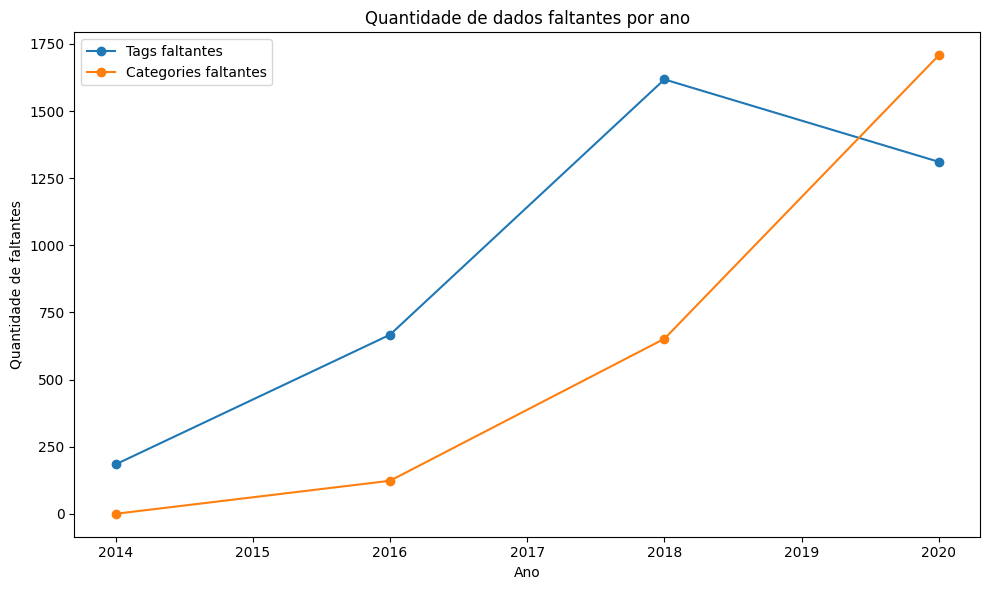

In [ ]:

def eh_faltante(x):
    return pd.isna(x) or x in ['', '[]', None]

df_filtro['tags_faltando'] = df_filtro['tags'].apply(eh_faltante)
df_filtro['categories_faltando'] = df_filtro['categories'].apply(eh_faltante)

faltantes_por_ano = df_filtro.groupby('year')[['tags_faltando', 'categories_faltando']].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(faltantes_por_ano['year'], faltantes_por_ano['tags_faltando'], label='Tags faltantes', marker='o')
plt.plot(faltantes_por_ano['year'], faltantes_por_ano['categories_faltando'], label='Categories faltantes', marker='o')
plt.title('Quantidade de dados faltantes por ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de faltantes')
plt.legend()
plt.tight_layout()
plt.show()


##Quais são as fontes que têm a variável categoria sem valores?



In [ ]:

# Tratar como ausente: NaN, '', '[]'
linhas_sem_categoria = df_filtro[df_filtro['categories'].isin([None, '', '[]']) | df_filtro['categories'].isna()]

# Ver fontes únicas
sources_sem_categoria = linhas_sem_categoria['source_name'].unique()

# Exibir
print("Fontes (source_name) com linhas sem categoria:")
for source in sources_sem_categoria:
    print(f"- {source}")


Fontes (source_name) com linhas sem categoria:
- ESTADAO_VERIFICA
- fato-ou-fake
- lupa


## Quais são essas linhas?

In [ ]:
df_filtro[df_filtro['source_name'].isin(['ESTADAO_VERIFICA', 'fato-ou-fake', 'lupa']) & df_filtro['categories'].isin([None, '', '[]']) | df_filtro['categories'].isna()]


,url,source_name,title,publication_date,text_news,categories,tags,obtained_at,rating,year,tags_faltando,categories_faltando
361,https://politica.estadao.com.br/blogs/estadao-...,ESTADAO_VERIFICA,Críticas aos direitos dos professores não fora...,2018-08-31,SAIBA MAIS\nA checagem abaixo foi publicada ...,[],"['joão amoêdo', 'educação']",2021-05-20,['ENGANOSO'],2018,False,True
362,https://politica.estadao.com.br/blogs/estadao-...,ESTADAO_VERIFICA,"Imagem de Marina Silva ‘invadindo fazenda’ é, ...",2018-08-24,A checagem abaixo foi publicada pelo Projeto C...,[],"['MST', 'comprova', 'marina silva', 'acre', 'c...",2021-05-20,['ENGANOSO'],2018,False,True
363,https://politica.estadao.com.br/blogs/estadao-...,ESTADAO_VERIFICA,Pesquisador agiu corretamente ao não mostrar q...,2018-08-24,A checagem abaixo foi publicada pelo Projeto C...,[],"['comprova', 'datafolha', 'pesquisa eleitoral']",2021-05-20,['ENGANOSO'],2018,False,True
364,https://politica.estadao.com.br/blogs/estadao-...,ESTADAO_VERIFICA,Imagem em post sobre ‘relatório da ONU favoráv...,2018-08-23,A checagem abaixo foi publicada pelo Projeto C...,[],"['lula', 'onu', 'comprova', 'psl']",2021-05-20,['ENGANOSO'],2018,False,True
365,https://politica.estadao.com.br/blogs/estadao-...,ESTADAO_VERIFICA,Pesquisa que mostra Bolsonaro vencendo em todo...,2018-08-23,A checagem abaixo foi publicada pelo Projeto C...,[],"['pesquisa', 'TSE', 'lula', 'jair bolsonaro']",2021-05-20,['ENGANOSO'],2018,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
11593,https://piaui.folha.uol.com.br/lupa/2016/11/17...,lupa,Que fim levaram as propostas feitas por Sérgio...,2016-11-17,"Na manhã desta quinta-feira (17), o ex-governa...",[],"['MARACANÃ', 'METRÔ', 'OBRAS', 'PROGRAMA DE GO...",2021-05-15,"['VERDADEIRO, MAS', 'VERDADEIRO, MAS', 'AINDA ...",2016,False,True
11594,https://piaui.folha.uol.com.br/lupa/2016/11/12...,lupa,Pezão diz que cortou o salário dele em 50%. Fo...,2016-11-12,"Nos últimos dias, o governador do Rio de Janei...",[],"['CRISE', 'FOLHA DE S.PAULO', 'FUNCIONALISMO P...",2021-05-15,"['EXAGERADO', 'EXAGERADO', 'EXAGERADO', 'VERDA...",2016,False,True
11595,https://piaui.folha.uol.com.br/lupa/2016/11/11...,lupa,"Em meio à crise, Pezão erra ao falar sobre fun...",2016-11-11,"Nos últimos dias, o governador do Rio, Luiz Fe...",[],"['CRISE', 'GOVERNO', 'GOVERNO ESTADUAL', 'LUIZ...",2021-05-15,"['EXAGERADO', 'VERDADEIRO, MAS', 'EXAGERADO', ...",2016,False,True
11596,https://piaui.folha.uol.com.br/lupa/2016/11/07...,lupa,Hillary derrapa ao falar de escândalo envolven...,2016-11-07,"Ao longo da corrida pela Casa Branca, a candid...",[],"['DEMOCRATA', 'ELEIÇÕES', 'ESTADO ISLÂMICO', '...",2021-05-15,"['FALSO', 'FALSO', 'FALSO', 'FALSO', 'FALSO']",2016,False,True


# "Drop" as linhas que têm valores vazios em text_news

In [ ]:
df_filtro = df_filtro.dropna(subset=['text_news'])
df_filtro = df_filtro.reset_index(drop=True)


# Quais são as categorias?

In [ ]:
print(df_filtro['categories'].unique())


["['Políticas públicas']" "['Pandemia']" "['Eleições']" '[]' nan
 'CORONAVÍRUS' 'Saúde' 'Brasil' 'Entretenimento' 'Política' 'Mundo'
 'Tecnologia' 'Lista' 'Religião' 'Esporte' 'Ciência' 'Opinião' 'NAS REDES'
 'CHECAMOS' '#VAMOSAOSFATOS' 'INVESTIGAMOS' 'INSTITUCIONAL'
 'ELEIÇÕES 2018' 'AOS FATOS LAB' 'ELEIÇÕES 2020' 'TEMPO REAL']


Describe:

In [ ]:
df_filtro.describe(include='all')

,url,source_name,title,publication_date,text_news,categories,tags,obtained_at,rating,year,tags_faltando,categories_faltando
count,6897,6897,6897,6897,6897,6423,6897,6897,6897,6897.000000,6897,6897
unique,6897,6,6850,NaN,6897,25,3068,10,711,NaN,2,2
top,https://projetocomprova.com.br/publica%C3%A7%C...,boatos,Vídeo distorce informações sobre o uso da clor...,NaN,Ancine aprovou em 2019 a captação de 530 mil r...,[],[],2021-06-01,['boato'],NaN,True,False
freq,1,3029,2,NaN,1,2009,3777,3029,3029,NaN,3777,4414
mean,NaN,NaN,NaN,2019-05-03 04:48:07.516311296,NaN,NaN,NaN,NaN,NaN,2018.783239,NaN,NaN
min,NaN,NaN,NaN,2014-01-04 00:00:00,NaN,NaN,NaN,NaN,NaN,2014.000000,NaN,NaN
25%,NaN,NaN,NaN,2018-07-13 00:00:00,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,NaN
50%,NaN,NaN,NaN,2020-03-09 00:00:00,NaN,NaN,NaN,NaN,NaN,2020.000000,NaN,NaN
75%,NaN,NaN,NaN,2020-08-07 00:00:00,NaN,NaN,NaN,NaN,NaN,2020.000000,NaN,NaN
max,NaN,NaN,NaN,2020-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,2020.000000,NaN,NaN


1. `url`: URLs das notícias (6.600 únicas, alta variabilidade).
2.` source_name: `Nome da fonte/agência (6 categorias distintas, sendo "boatos" a mais frequente, com 3.032 ocorrências
3.` title:` Títulos das notícias (6.653 únicos, alta diversidade).
4. `text_name:` Texto principal (6.997 únicos, quase todos distintos).

4. `categories`:Categorias (25 únicas, com uma categoria dominante em 2.099 ocorrências).

6. `tags:` Tags (3.068 únicas, mas 3.780 valores ausentes).

## Normalização e conversão para lista das categorias tags e categories

In [ ]:
def convert_to_list(value):
    if pd.isna(value) or value in ['', '[]']:
        return []
    try:
        # Remove aspas extras e converte string de lista para lista
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        # Se não for uma lista válida, trata como valor único
        return [value]

df_filtro['tags'] = df_filtro['tags'].apply(convert_to_list)
df_filtro['categories'] = df_filtro['categories'].apply(convert_to_list)

def normalize_text(text):
    if isinstance(text, list):
        return [normalize_text(item) for item in text]
    # Converter para minúsculas
    text = text.lower()
    # Remover acentos
    text = unicodedata.normalize('NFKD', text).encode('ASCII', 'ignore').decode('ASCII')
    # Remover caracteres especiais (opcional)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.strip()

df_filtro['tags'] = df_filtro['tags'].apply(lambda x: [normalize_text(tag) for tag in x])
df_filtro['categories'] = df_filtro['categories'].apply(lambda x: [normalize_text(cat) for cat in x])

# Preenchendo valores vazios

In [ ]:
df_filtro['tags'] = df_filtro['tags'].apply(lambda x: 'desconhecido' if x == [] else x)

In [ ]:
df_filtro['categories'] = df_filtro['categories'].apply(
    lambda x: ["desconhecido"] if (not x or x == ["[]"]) else x
)

In [ ]:
df_filtro['categories']

,categories
0,[politicas publicas]
1,[politicas publicas]
2,[pandemia]
3,[pandemia]
4,[pandemia]
...,...
6892,[desconhecido]
6893,[desconhecido]
6894,[desconhecido]
6895,[desconhecido]


In [ ]:
df_filtro['categories'] = df_filtro['categories'].apply(
    lambda x: "desconhecido" if (pd.isna(x) or x == "[]" or x == "") else x
)
df_filtro


,url,source_name,title,publication_date,text_news,categories,tags,obtained_at,rating,year,tags_faltando,categories_faltando
0,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Publicações enganam ao associar Bolsonaro à ap...,2020-07-31,Ancine aprovou em 2019 a captação de 530 mil r...,[politicas publicas],desconhecido,2021-07-06,['Enganoso'],2020,True,False
1,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Post mostra imagens de outras estradas para af...,2020-07-31,Parte dos trechos das gravações utilizadas no ...,[politicas publicas],desconhecido,2021-07-06,['Falso'],2020,True,False
2,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Eduardo Bolsonaro posta vídeo antigo sobre lib...,2020-07-31,"Em uma publicação no Twitter, o deputado usa c...",[pandemia],desconhecido,2021-07-06,['Enganoso'],2020,True,False
3,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Médica cita estudos não conclusivos para suger...,2020-07-30,"Procurada pelo Comprova, médica enviou 34 estu...",[pandemia],desconhecido,2021-07-06,['Enganoso'],2020,True,False
4,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Médica usa informações falsas em vídeo para fa...,2020-07-29,Ao contrário do que afirma uma médica em vídeo...,[pandemia],desconhecido,2021-07-06,['Falso'],2020,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
6892,https://piaui.folha.uol.com.br/lupa/2016/11/17...,lupa,Que fim levaram as propostas feitas por Sérgio...,2016-11-17,"Na manhã desta quinta-feira (17), o ex-governa...",[desconhecido],"[maracana, metro, obras, programa de governo, ...",2021-05-15,"['VERDADEIRO, MAS', 'VERDADEIRO, MAS', 'AINDA ...",2016,False,True
6893,https://piaui.folha.uol.com.br/lupa/2016/11/12...,lupa,Pezão diz que cortou o salário dele em 50%. Fo...,2016-11-12,"Nos últimos dias, o governador do Rio de Janei...",[desconhecido],"[crise, folha de spaulo, funcionalismo publico...",2021-05-15,"['EXAGERADO', 'EXAGERADO', 'EXAGERADO', 'VERDA...",2016,False,True
6894,https://piaui.folha.uol.com.br/lupa/2016/11/11...,lupa,"Em meio à crise, Pezão erra ao falar sobre fun...",2016-11-11,"Nos últimos dias, o governador do Rio, Luiz Fe...",[desconhecido],"[crise, governo, governo estadual, luiz fernan...",2021-05-15,"['EXAGERADO', 'VERDADEIRO, MAS', 'EXAGERADO', ...",2016,False,True
6895,https://piaui.folha.uol.com.br/lupa/2016/11/07...,lupa,Hillary derrapa ao falar de escândalo envolven...,2016-11-07,"Ao longo da corrida pela Casa Branca, a candid...",[desconhecido],"[democrata, eleicoes, estado islamico, estados...",2021-05-15,"['FALSO', 'FALSO', 'FALSO', 'FALSO', 'FALSO']",2016,False,True


In [ ]:
df_filtro = df_filtro.drop(columns=['tags_faltando', 'categories_faltando'])

# Normalizar a coluna rating

In [ ]:

def normalizar_lista_rating(item):
    try:
        lista = ast.literal_eval(item) if isinstance(item, str) else item
        if isinstance(lista, list):
            return [x.strip().upper() for x in lista]
        return []
    except:
        return []

df_filtro['rating'] = df_filtro['rating'].apply(normalizar_lista_rating)

In [ ]:
df_filtro['rating']

,rating
0,[ENGANOSO]
1,[FALSO]
2,[ENGANOSO]
3,[ENGANOSO]
4,[FALSO]
...,...
6892,"[VERDADEIRO, MAS, VERDADEIRO, MAS, AINDA É CED..."
6893,"[EXAGERADO, EXAGERADO, EXAGERADO, VERDADEIRO, ..."
6894,"[EXAGERADO, VERDADEIRO, MAS, EXAGERADO, EXAGER..."
6895,"[FALSO, FALSO, FALSO, FALSO, FALSO]"


# Extrair todos os valores únicos das listas em 'rating'


In [ ]:

# Extrair todos os valores únicos das listas em 'rating'
all_ratings = []

for item in df_filtro['rating']:
    try:
        # Converte a string de lista para uma lista real pra auxiliar na contagem de cada valor
        lista = ast.literal_eval(item) if isinstance(item, str) else item
        if isinstance(lista, list):
            all_ratings.extend([r.strip().upper() for r in lista])  # Limpa e normaliza
    except:
        continue  # pula valores com erro

# Contar a frequência de cada valor
rating_counts = Counter(all_ratings)

print("Frequência de valores em 'rating':")
for rating, count in rating_counts.most_common():
    print(f"{rating}: {count}")


Frequência de valores em 'rating':
FALSO: 4166
BOATO: 3029
VERDADEIRO: 1549
FAKE: 806
EXAGERADO: 748
VERDADEIRO, MAS: 488
FATO: 384
NAO E BEM ASSIM: 340
IMPRECISO: 299
ENGANOSO: 231
INSUSTENTÁVEL: 160
CONTRADITÓRIO: 141
DE OLHO: 140
FORA DE CONTEXTO: 96
DISTORCIDO: 71
SUBESTIMADO: 66
AINDA É CEDO PARA DIZER: 56
COMPROVADO: 6


Mapeamento do rating

In [ ]:
mapa_rating = {
    # 0 - Totalmente falso
    'FALSO': 0,
    'FAKE': 0,
    'BOATO': 0,

    # 1 - Parcialmente falso ou distorcido
    'ENGANOSO': 1,
    'IMPRECISO': 1,
    'FORA DE CONTEXTO': 1,
    'DISTORCIDO': 1,
    'INSUSTENTÁVEL': 1,
    'EXAGERADO': 1,

    # 2 - Ambíguo
    'NAO E BEM ASSIM': 2,
    'CONTRADITÓRIO': 2,
    'DE OLHO': 2,
    'AINDA É CEDO PARA DIZER': 2,
    'SUBESTIMADO': 2,
    'VERDADEIRO, MAS': 2,



    # 4 - Totalmente verdadeiro
    'VERDADEIRO': 3,
    'FATO': 3,
    'COMPROVADO': 3
}


# **Criando coluna rating escala, que é calculada a partir da média média do mapeamento criado acima**

In [ ]:
def calcular_media_rating(lista):
    valores = [mapa_rating.get(item, None) for item in lista]
    valores = [v for v in valores if v is not None]
    return round(sum(valores) / len(valores), 2) if valores else None


# Aplicando no DataFrame
df_filtro['rating_escala'] = df_filtro['rating'].apply(calcular_media_rating)

In [ ]:
df_filtro

,url,source_name,title,publication_date,text_news,categories,tags,obtained_at,rating,year,rating_escala
0,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Publicações enganam ao associar Bolsonaro à ap...,2020-07-31,Ancine aprovou em 2019 a captação de 530 mil r...,[politicas publicas],desconhecido,2021-07-06,[ENGANOSO],2020,1.00
1,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Post mostra imagens de outras estradas para af...,2020-07-31,Parte dos trechos das gravações utilizadas no ...,[politicas publicas],desconhecido,2021-07-06,[FALSO],2020,0.00
2,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Eduardo Bolsonaro posta vídeo antigo sobre lib...,2020-07-31,"Em uma publicação no Twitter, o deputado usa c...",[pandemia],desconhecido,2021-07-06,[ENGANOSO],2020,1.00
3,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Médica cita estudos não conclusivos para suger...,2020-07-30,"Procurada pelo Comprova, médica enviou 34 estu...",[pandemia],desconhecido,2021-07-06,[ENGANOSO],2020,1.00
4,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Médica usa informações falsas em vídeo para fa...,2020-07-29,Ao contrário do que afirma uma médica em vídeo...,[pandemia],desconhecido,2021-07-06,[FALSO],2020,0.00
...,...,...,...,...,...,...,...,...,...,...,...
6892,https://piaui.folha.uol.com.br/lupa/2016/11/17...,lupa,Que fim levaram as propostas feitas por Sérgio...,2016-11-17,"Na manhã desta quinta-feira (17), o ex-governa...",[desconhecido],"[maracana, metro, obras, programa de governo, ...",2021-05-15,"[VERDADEIRO, MAS, VERDADEIRO, MAS, AINDA É CED...",2016,1.43
6893,https://piaui.folha.uol.com.br/lupa/2016/11/12...,lupa,Pezão diz que cortou o salário dele em 50%. Fo...,2016-11-12,"Nos últimos dias, o governador do Rio de Janei...",[desconhecido],"[crise, folha de spaulo, funcionalismo publico...",2021-05-15,"[EXAGERADO, EXAGERADO, EXAGERADO, VERDADEIRO, ...",2016,1.25
6894,https://piaui.folha.uol.com.br/lupa/2016/11/11...,lupa,"Em meio à crise, Pezão erra ao falar sobre fun...",2016-11-11,"Nos últimos dias, o governador do Rio, Luiz Fe...",[desconhecido],"[crise, governo, governo estadual, luiz fernan...",2021-05-15,"[EXAGERADO, VERDADEIRO, MAS, EXAGERADO, EXAGER...",2016,1.40
6895,https://piaui.folha.uol.com.br/lupa/2016/11/07...,lupa,Hillary derrapa ao falar de escândalo envolven...,2016-11-07,"Ao longo da corrida pela Casa Branca, a candid...",[desconhecido],"[democrata, eleicoes, estado islamico, estados...",2021-05-15,"[FALSO, FALSO, FALSO, FALSO, FALSO]",2016,0.00


# 4. Análise descritiva

Estilos disponíveis: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


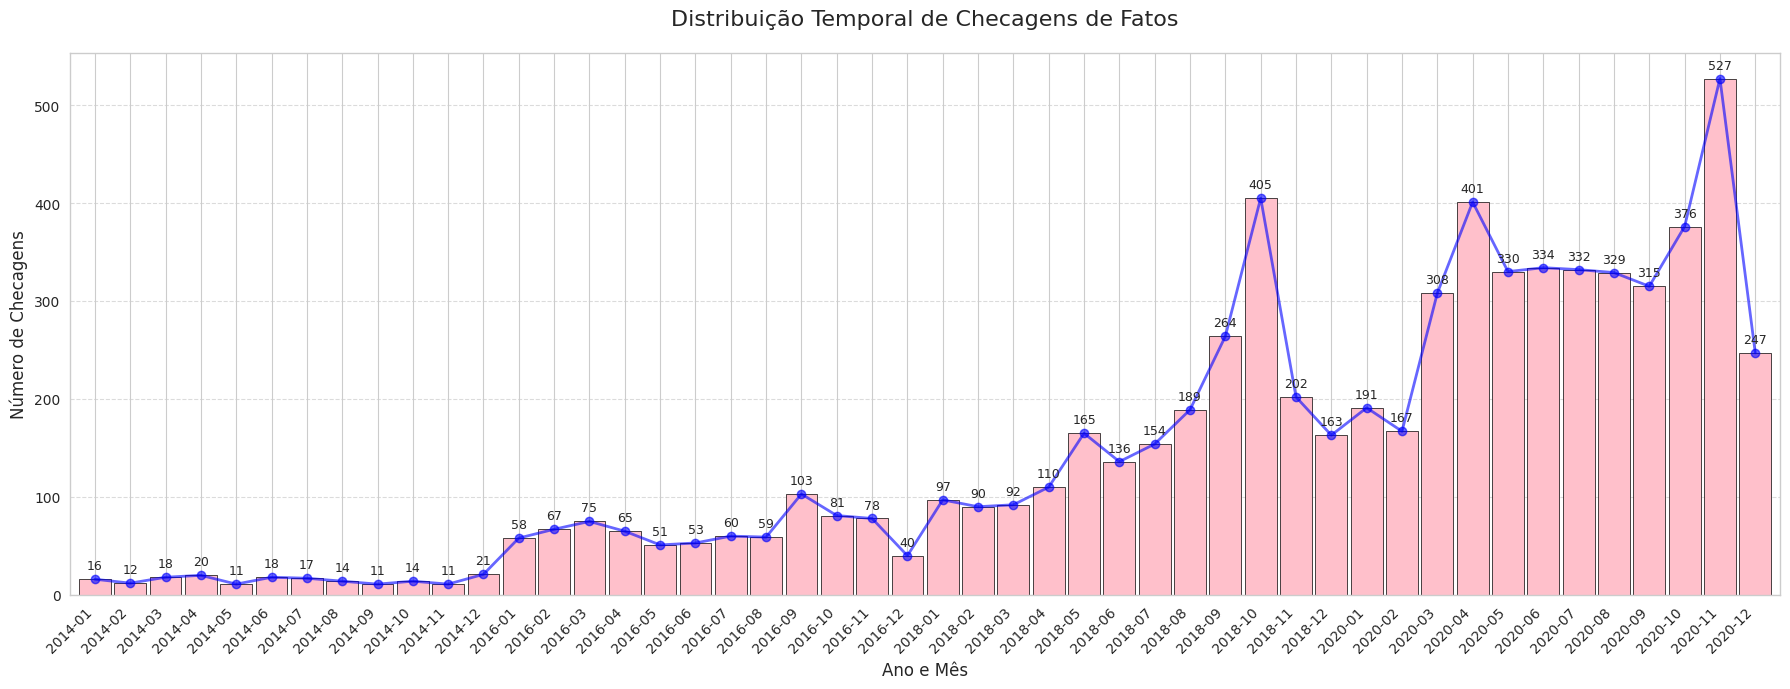

In [ ]:
# Verificar estilos disponíveis
print("Estilos disponíveis:", plt.style.available)

# Garantir que data está em datetime
df_filtro['publication_date'] = pd.to_datetime(df_filtro['publication_date'])
df_filtro['year'] = df_filtro['publication_date'].dt.year
df_filtro['month'] = df_filtro['publication_date'].dt.month
df_filtro['year_month'] = df_filtro['publication_date'].dt.to_period('M')

# Estilo
plt.style.use('ggplot')
sns.set_style("whitegrid")
sns.set_palette("husl")

# Figura
plt.figure(figsize=(18, 7))

# Contagem por mês/ano
counts = df_filtro['year_month'].value_counts().sort_index()

# Gráfico de barras
ax = counts.plot(kind='bar', width=0.9, color='pink', edgecolor='black')

# Títulos e eixos
plt.title('Distribuição Temporal de Checagens de Fatos', fontsize=16, pad=20)
plt.xlabel('Ano e Mês', fontsize=12)
plt.ylabel('Número de Checagens', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)

# Grade horizontal
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Anotar valores nas barras
for i, v in enumerate(counts):
    if v > 0:
        ax.annotate(str(v), xy=(i, v), xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

# Linha de tendência sobre as barras
ax.plot(range(len(counts)), counts.values, color='blue', alpha=0.6, marker='o', linewidth=2)

# Ajuste final
plt.tight_layout()
plt.show()


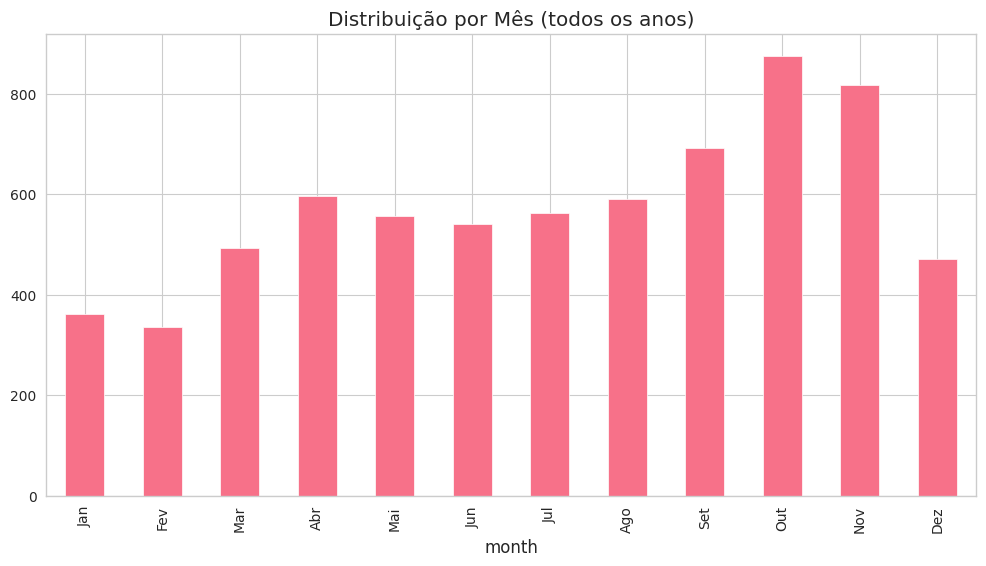

In [ ]:
# Padrões sazonais
plt.figure(figsize=(12, 6))
df_filtro['month'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribuição por Mês (todos os anos)')
plt.xticks(range(12), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.show()

In [ ]:
contagem_por_ano_mes = df_filtro.groupby(['year', 'month']).size().reset_index(name='count')


In [ ]:
cross_tab = contagem_por_ano_mes.pivot(index='year', columns='month', values='count').fillna(0).astype(int)


In [ ]:
df_filtro[df_filtro['year'] == 2016].shape[0]  # Esperado: 697?


790

In [ ]:

cross_tab.loc[2016].sum()  # Resultado do heatmap (aparentemente 790)


790

In [ ]:
contagem_por_ano_mes = df_filtro.groupby(['year', 'month']).size().reset_index(name='count')
cross_tab = contagem_por_ano_mes.pivot(index='year', columns='month', values='count').fillna(0).astype(int)


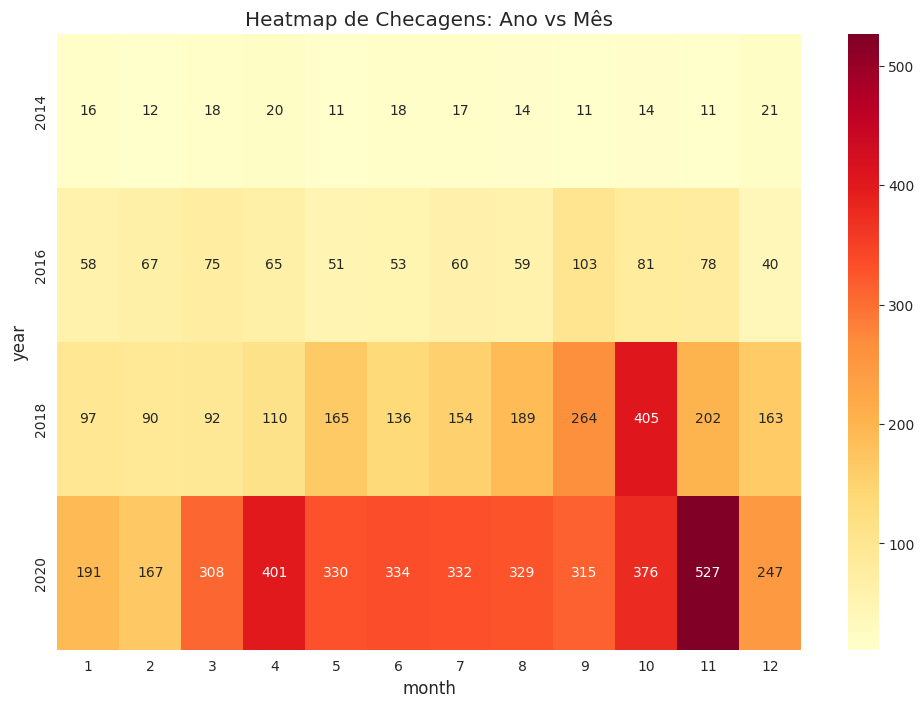

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Heatmap de Checagens: Ano vs Mês')
plt.xlabel('month')
plt.ylabel('year')
plt.show()


<Axes: xlabel='categories'>

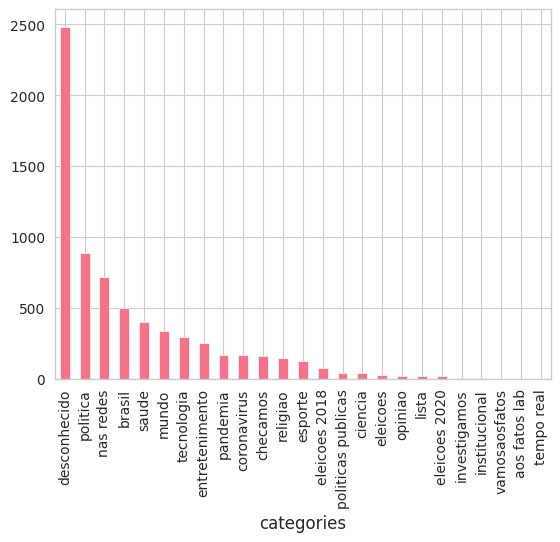

In [ ]:

def safe_convert(x):
    if isinstance(x, list):  # If already a list, return as-is
        return x
    try:
        return ast.literal_eval(x)  # If string like "['x']", convert to list
    except (ValueError, SyntaxError):
        return [x]  # If malformed, wrap in a list

categories = df_filtro['categories'].apply(safe_convert).explode()
categories.value_counts().plot(kind='bar')

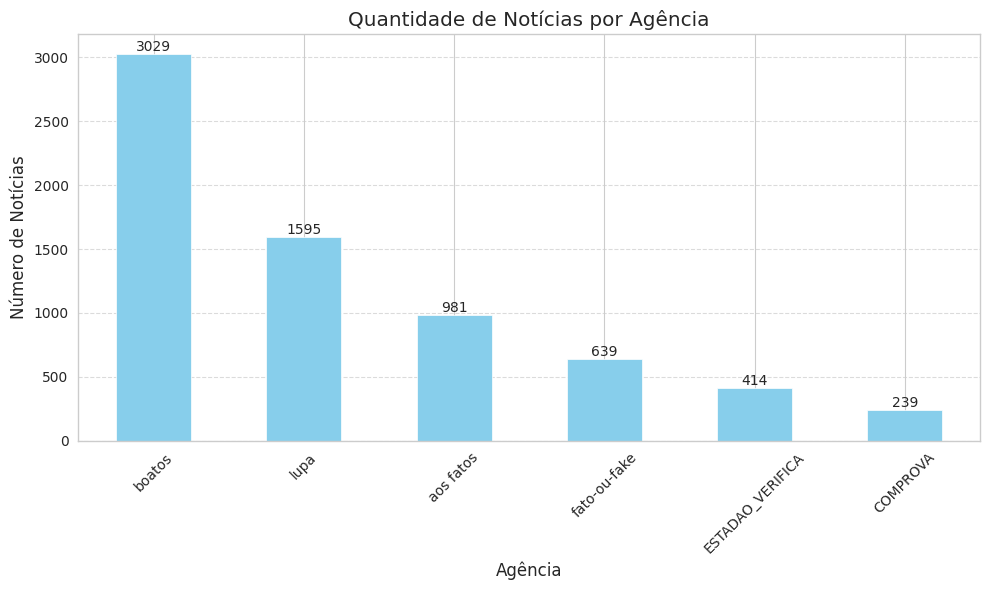

In [ ]:
# Contar notícias por agência
contagem_agencias = df_filtro['source_name'].value_counts()

# Criar o gráfico de barras
ax = contagem_agencias.plot(kind='bar', color='skyblue', figsize=(10, 6))

# Adicionar os valores em cima das barras
for i, valor in enumerate(contagem_agencias):
    ax.text(i, valor + 0.5, str(valor), ha='center', va='bottom')  # +0.5 para espaçamento

# Personalizar o gráfico
plt.title('Quantidade de Notícias por Agência')
plt.xlabel('Agência')
plt.ylabel('Número de Notícias')
plt.xticks(rotation=45)  # Rotacionar nomes das agências se necessário
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()  # Ajustar layout para evitar cortes
plt.show()

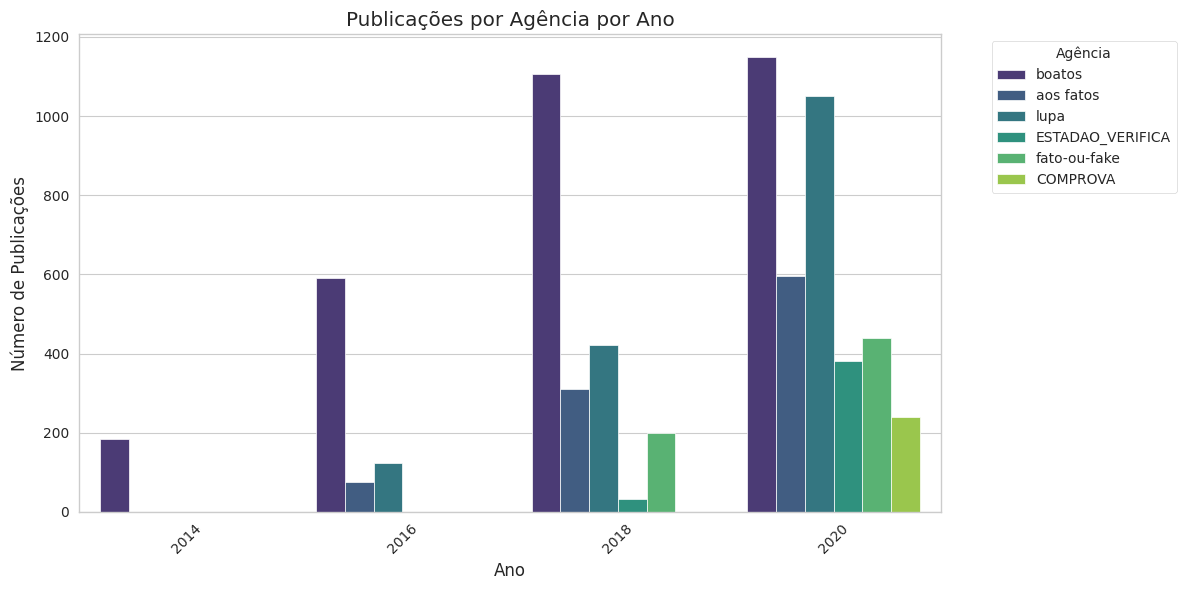

In [ ]:
publicacoes_por_ano_agencia = df_filtro.groupby(['year', 'source_name']).size().reset_index(name='count')
plt.figure(figsize=(12, 6))
sns.barplot(
    data=publicacoes_por_ano_agencia,
    x='year',
    y='count',
    hue='source_name',
    palette='viridis'
)

plt.title('Publicações por Agência por Ano')
plt.xlabel('Ano')
plt.ylabel('Número de Publicações')
plt.legend(title='Agência', bbox_to_anchor=(1.05, 1))  # Legenda fora do gráfico
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

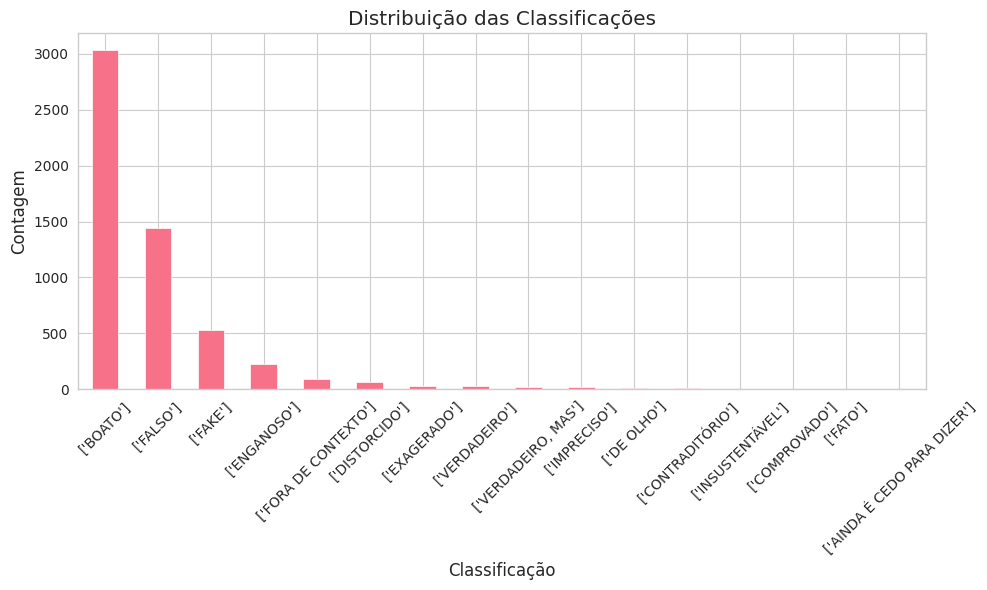

In [ ]:
def parse_categorical_rating(rating_str):
    try:
        if pd.isna(rating_str):
            return None

        # Handle list format
        if isinstance(rating_str, str) and rating_str.startswith('['):
            return rating_str.strip('[]').split(',')[0].strip().strip("'\"")

        return str(rating_str).strip()
    except:
        return None

df_filtro['rating'] = df_filtro['rating'].apply(parse_categorical_rating)
df_filtro = df_filtro.dropna(subset=['rating'])

# Plot with better formatting
ax = df_filtro['rating'].value_counts().plot(
    kind='bar',
    title='Distribuição das Classificações',
    figsize=(10, 6)
)
ax.set_xlabel('Classificação')
ax.set_ylabel('Contagem')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

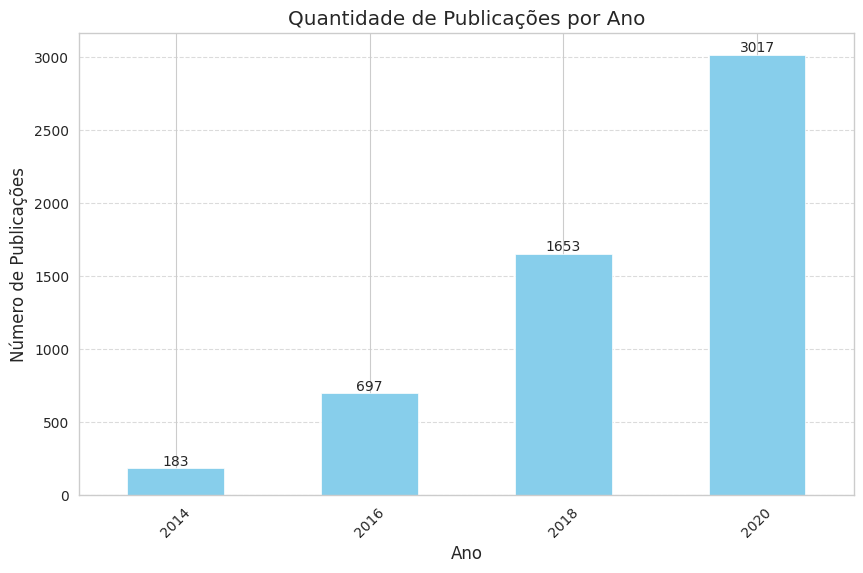

In [ ]:

# Contar objetos por ano e ordenar
contagem_por_ano = df_filtro['year'].value_counts().sort_index()

# Plotar o gráfico de barras
ax = contagem_por_ano.plot(kind='bar', color='skyblue', figsize=(10, 6))

# Adicionar os valores em cima das barras
for i, valor in enumerate(contagem_por_ano):
    ax.text(i, valor + 0.2, str(valor), ha='center', va='bottom')  # +0.2 para espaçamento

# Personalizar
plt.title('Quantidade de Publicações por Ano')
plt.xlabel('Ano')
plt.ylabel('Número de Publicações')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

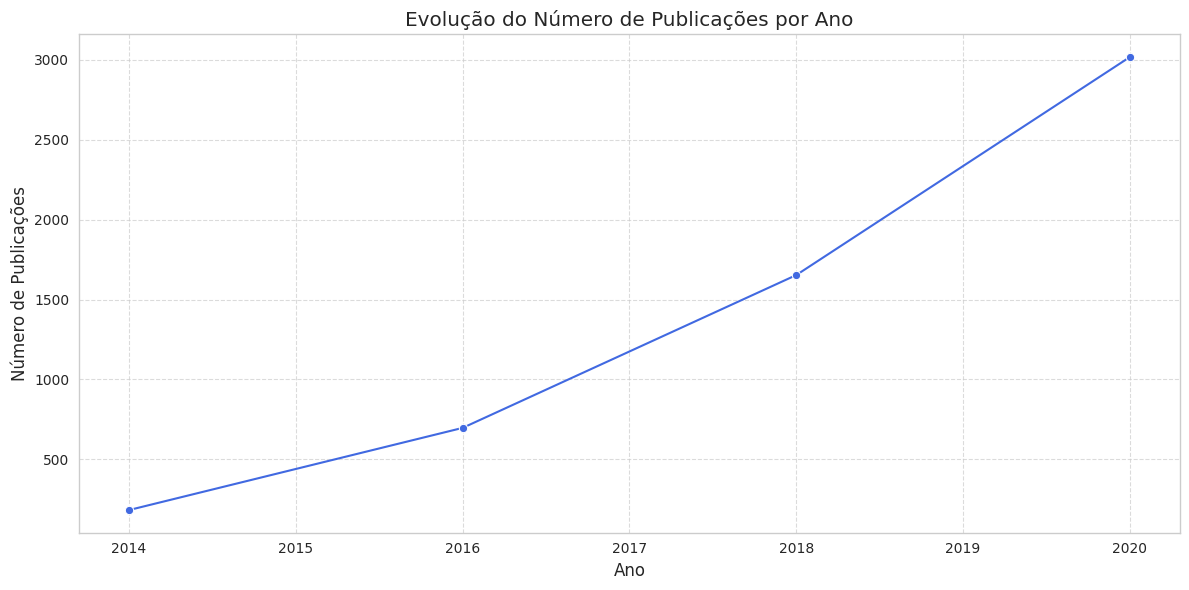

In [ ]:
# Agrupar por ano e contar publicações
publicacoes_por_ano = df_filtro['year'].value_counts().sort_index().reset_index()
publicacoes_por_ano.columns = ['Ano', 'Número de Publicações']

# Gráfico de linha
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=publicacoes_por_ano,
    x='Ano',
    y='Número de Publicações',
    marker='o',
    color='royalblue'
)
plt.title('Evolução do Número de Publicações por Ano')
plt.xlabel('Ano')
plt.ylabel('Número de Publicações')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

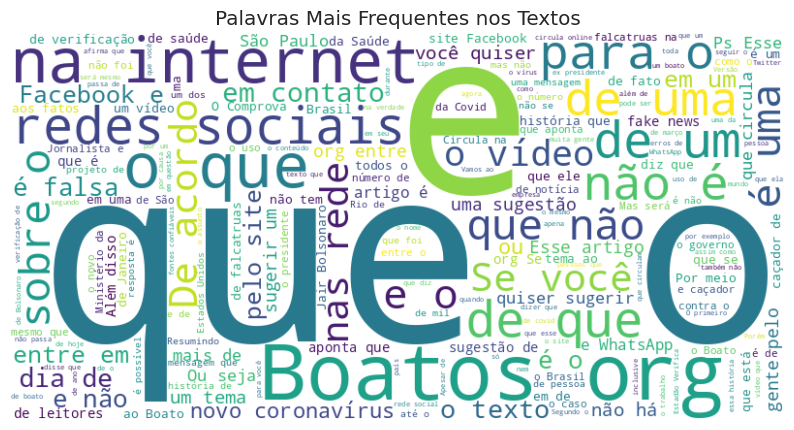

In [ ]:
from wordcloud import WordCloud

# Concatenar todos os títulos
texto = ' '.join(df_filtro['text_news'].dropna())

# Gerar nuvem de palavras
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(texto)

# Plotar
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palavras Mais Frequentes nos Textos')
plt.show()

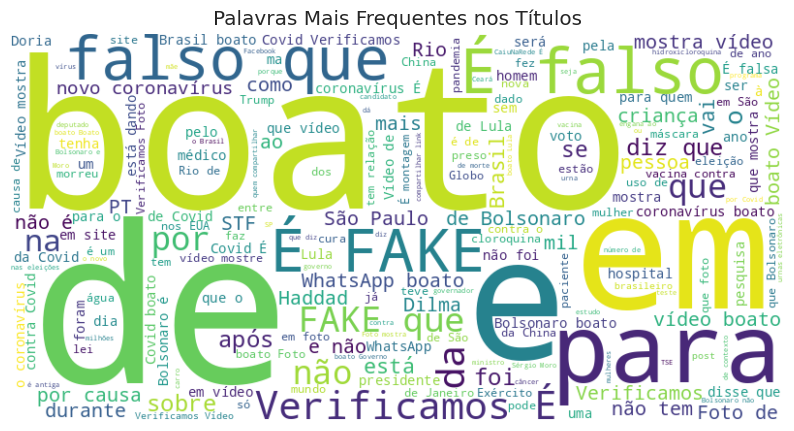

In [ ]:
from wordcloud import WordCloud

# Concatenar todos os títulos
texto = ' '.join(df_filtro['title'].dropna())

# Gerar nuvem de palavras
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(texto)

# Plotar
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palavras Mais Frequentes nos Títulos')
plt.show()

## Seleção da amostra

In [ ]:
proporcoes_ano = df_filtro['year'].value_counts(normalize=True)
print(proporcoes_ano)

year
2020    0.543604
2018    0.297838
2016    0.125586
2014    0.032973
Name: proportion, dtype: float64


In [ ]:
proporcoes = df_filtro['source_name'].value_counts(normalize=True)
print(proporcoes)

source_name
boatos              0.545766
lupa                0.179820
fato-ou-fake        0.096937
ESTADAO_VERIFICA    0.074595
aos fatos           0.059820
COMPROVA            0.043063
Name: proportion, dtype: float64


In [ ]:
df_filtro.to_csv('/content/gdrive/MyDrive/dados_filtrado.csv', index=False)


In [ ]:
df_filtro

,url,source_name,title,publication_date,text_news,categories,tags,obtained_at,rating,year,rating_escala,month,year_month
0,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Publicações enganam ao associar Bolsonaro à ap...,2020-07-31,Ancine aprovou em 2019 a captação de 530 mil r...,[politicas publicas],desconhecido,2021-07-06,['ENGANOSO'],2020,1.0,7,2020-07
1,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Post mostra imagens de outras estradas para af...,2020-07-31,Parte dos trechos das gravações utilizadas no ...,[politicas publicas],desconhecido,2021-07-06,['FALSO'],2020,0.0,7,2020-07
2,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Eduardo Bolsonaro posta vídeo antigo sobre lib...,2020-07-31,"Em uma publicação no Twitter, o deputado usa c...",[pandemia],desconhecido,2021-07-06,['ENGANOSO'],2020,1.0,7,2020-07
3,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Médica cita estudos não conclusivos para suger...,2020-07-30,"Procurada pelo Comprova, médica enviou 34 estu...",[pandemia],desconhecido,2021-07-06,['ENGANOSO'],2020,1.0,7,2020-07
4,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Médica usa informações falsas em vídeo para fa...,2020-07-29,Ao contrário do que afirma uma médica em vídeo...,[pandemia],desconhecido,2021-07-06,['FALSO'],2020,0.0,7,2020-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6885,https://piaui.folha.uol.com.br/lupa/2020/03/04...,lupa,#Verificamos: É falso que padre de São José do...,2020-03-04,Circula pelas redes sociais um vídeo com uma p...,[desconhecido],"[verificamos, 15 de marco, catedral de sao dim...",2021-05-14,['FALSO'],2020,0.0,3,2020-03
6886,https://piaui.folha.uol.com.br/lupa/2020/03/03...,lupa,#Verificamos: É falso que vinagre é mais efici...,2020-03-03,Circula nas redes sociais um vídeo de um homem...,[desconhecido],"[verificamos, alcool gel, conselho federal de ...",2021-05-14,['FALSO'],2020,0.0,3,2020-03
6887,https://piaui.folha.uol.com.br/lupa/2020/03/03...,lupa,#Verificamos: É falso que Os Simpsons previram...,2020-03-03,Circula pelas redes sociais uma montagem com q...,[desconhecido],"[verificamos, china, coronavirus, covid19, des...",2021-05-14,['FALSO'],2020,0.0,3,2020-03
6888,https://piaui.folha.uol.com.br/lupa/2020/03/02...,lupa,#Verificamos: Vídeo com famosos convidando a p...,2020-03-02,Circula nas redes sociais um vídeo no qual vár...,[desconhecido],"[verificamos, 15 de marco, 2015, alessandra ma...",2021-05-14,['FALSO'],2020,0.0,3,2020-03


In [ ]:
  df_filtro

,url,source_name,title,publication_date,text_news,categories,tags,obtained_at,rating,year,rating_escala,month,year_month
0,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Publicações enganam ao associar Bolsonaro à ap...,2020-07-31,Ancine aprovou em 2019 a captação de 530 mil r...,[politicas publicas],desconhecido,2021-07-06,['ENGANOSO'],2020,1.0,7,2020-07
1,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Post mostra imagens de outras estradas para af...,2020-07-31,Parte dos trechos das gravações utilizadas no ...,[politicas publicas],desconhecido,2021-07-06,['FALSO'],2020,0.0,7,2020-07
2,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Eduardo Bolsonaro posta vídeo antigo sobre lib...,2020-07-31,"Em uma publicação no Twitter, o deputado usa c...",[pandemia],desconhecido,2021-07-06,['ENGANOSO'],2020,1.0,7,2020-07
3,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Médica cita estudos não conclusivos para suger...,2020-07-30,"Procurada pelo Comprova, médica enviou 34 estu...",[pandemia],desconhecido,2021-07-06,['ENGANOSO'],2020,1.0,7,2020-07
4,https://projetocomprova.com.br/publica%C3%A7%C...,COMPROVA,Médica usa informações falsas em vídeo para fa...,2020-07-29,Ao contrário do que afirma uma médica em vídeo...,[pandemia],desconhecido,2021-07-06,['FALSO'],2020,0.0,7,2020-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6885,https://piaui.folha.uol.com.br/lupa/2020/03/04...,lupa,#Verificamos: É falso que padre de São José do...,2020-03-04,Circula pelas redes sociais um vídeo com uma p...,[desconhecido],"[verificamos, 15 de marco, catedral de sao dim...",2021-05-14,['FALSO'],2020,0.0,3,2020-03
6886,https://piaui.folha.uol.com.br/lupa/2020/03/03...,lupa,#Verificamos: É falso que vinagre é mais efici...,2020-03-03,Circula nas redes sociais um vídeo de um homem...,[desconhecido],"[verificamos, alcool gel, conselho federal de ...",2021-05-14,['FALSO'],2020,0.0,3,2020-03
6887,https://piaui.folha.uol.com.br/lupa/2020/03/03...,lupa,#Verificamos: É falso que Os Simpsons previram...,2020-03-03,Circula pelas redes sociais uma montagem com q...,[desconhecido],"[verificamos, china, coronavirus, covid19, des...",2021-05-14,['FALSO'],2020,0.0,3,2020-03
6888,https://piaui.folha.uol.com.br/lupa/2020/03/02...,lupa,#Verificamos: Vídeo com famosos convidando a p...,2020-03-02,Circula nas redes sociais um vídeo no qual vár...,[desconhecido],"[verificamos, 15 de marco, 2015, alessandra ma...",2021-05-14,['FALSO'],2020,0.0,3,2020-03


## adicionar agência e ano

In [ ]:
# coluna que combine source_name e year para estratificação conjunta
df_filtro['strata'] = df_filtro['source_name'].astype(str) + '_' + df_filtro['year'].astype(str)

tamanho_amostra = int(0.30 * len(df_filtro))

# amostra estratificada baseada na coluna 'strata'
df_strata, _ = train_test_split(
    df_filtro,
    train_size=tamanho_amostra,
    stratify=df_filtro['strata'],
    random_state=42
)

df_strata = df_strata.drop(columns=['strata'])



/tmp/ipython-input-53-313117204.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtro['strata'] = df_filtro['source_name'].astype(str) + '_' + df_filtro['year'].astype(str)


In [ ]:
df_strata

,url,source_name,title,publication_date,text_news,categories,tags,obtained_at,rating,year,rating_escala,month,year_month
2145,https://www.boatos.org/brasil/restaurante-gale...,boatos,Restaurante Galeto’s entrou em falência e fech...,2020-05-14,"O isolamento social, mesmo sendo a melhor mane...",[brasil],"[boato, restaurante, galetos, falencia, sp, br...",2021-06-01,['BOATO'],2020,0.0,5,2020-05
746,https://g1.globo.com/fato-ou-fake/noticia/2020...,fato-ou-fake,"É #FAKE que nova moeda, chamada DIM, está prog...",2020-07-30,Circula pelas redes sociais um cartaz que diz ...,[desconhecido],desconhecido,2021-05-30,['FAKE'],2020,0.0,7,2020-07
959,https://g1.globo.com/fato-ou-fake/noticia/2020...,fato-ou-fake,É #FAKE que Ministério da Saúde orienta parent...,2020-04-02,Uma mensagem com o logotipo do Ministério da S...,[desconhecido],desconhecido,2021-05-30,['FAKE'],2020,0.0,4,2020-04
2629,https://www.boatos.org/tecnologia/boticario-na...,boatos,O Boticário está dando creme Nativa SPA Karité...,2018-10-18,Já falamos aqui que o único tipo de boato não-...,[tecnologia],desconhecido,2021-06-01,['BOATO'],2018,0.0,10,2018-10
3397,https://www.boatos.org/saude/feijao-esta-com-b...,boatos,Bactéria no feijão vem das plantações; deixe d...,2016-09-06,Em 2015 um dos boatos que mais circularam na i...,[saude],desconhecido,2021-06-01,['BOATO'],2016,0.0,9,2016-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,https://g1.globo.com/fato-ou-fake/noticia/2020...,fato-ou-fake,É #FAKE que auto-hemoterapia cure a Covid-19,2020-03-24,Circula pelas redes sociais um vídeo em que um...,[desconhecido],desconhecido,2021-05-30,['FAKE'],2020,0.0,3,2020-03
5147,https://www.aosfatos.org/noticias/nao-ha-proje...,aos fatos,Não há projeto de lei para legalizar a pedofil...,2018-10-15,Circula nas redes sociais uma montagem com uma...,[nas redes],desconhecido,2021-05-30,['FALSO'],2018,0.0,10,2018-10
1812,https://www.boatos.org/politica/bolsonaro-cont...,boatos,Bolsonaro descobriu conta secreta de R$ 600 bi...,2020-08-27,"De uns tempos para cá, houve um crescimento ex...",[politica],"[boato, bolsonaro, descobriu, r600bilhdes, bc,...",2021-06-01,['BOATO'],2020,0.0,8,2020-08
3037,https://www.boatos.org/politica/maria-clara-ri...,boatos,Maria Clara Ribeiro Tarabal é procurada pelo a...,2018-09-10,Dentre todos os absurdos que têm surgido após ...,[politica],desconhecido,2021-06-01,['BOATO'],2018,0.0,9,2018-09


## **PRE PROCESSAMENTO DO TEXTO**

In [ ]:
!pip install nltk  # Para processamento de texto


## 2. Remoção de palavras e conteúdo desnecessários


In [ ]:


nltk.download('stopwords')
nltk.download('punkt')
nltk.download('rslp')  # Para stemmer em português

# Carregar stopwords em português
stop_words = set(stopwords.words('portuguese'))

stop_words.update(["o", "a", "os", "as", "um", "uma", "uns", "umas", "de", "da", "do", "das", "dos"])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


In [ ]:
!pip install unidecode

In [ ]:
from unidecode import unidecode

In [ ]:
def preprocessar_texto(texto, aplicar_stemmer=False):
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = unidecode(texto)

    # Remover pontuações, números, etc.
    texto = re.sub('\s+', ' ', texto)  # Remove extra spaces
    texto = re.sub('\S*@\S*\s?', '', texto)  # Remove emails
    texto = re.sub('\'', '', texto)  # Remove apostrophes
    texto = re.sub('[^a-zA-Z]', ' ', texto)  # Remove non-alphabet

    texto = texto.lower()

    # Tokenizar
    tokens = word_tokenize(texto, language='portuguese')

    # Remover stopwords
    tokens = [palavra for palavra in tokens if palavra not in stop_words and len(palavra) > 2]

    return " ".join(tokens)


In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# aplique o pré-processamento básico
df_strata['title_limpo'] = df_strata['title'].astype(str).apply(preprocessar_texto)
df_strata['text_news_limpo'] = df_strata['text_news'].astype(str).apply(preprocessar_texto)

/tmp/ipython-input-62-3824403297.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


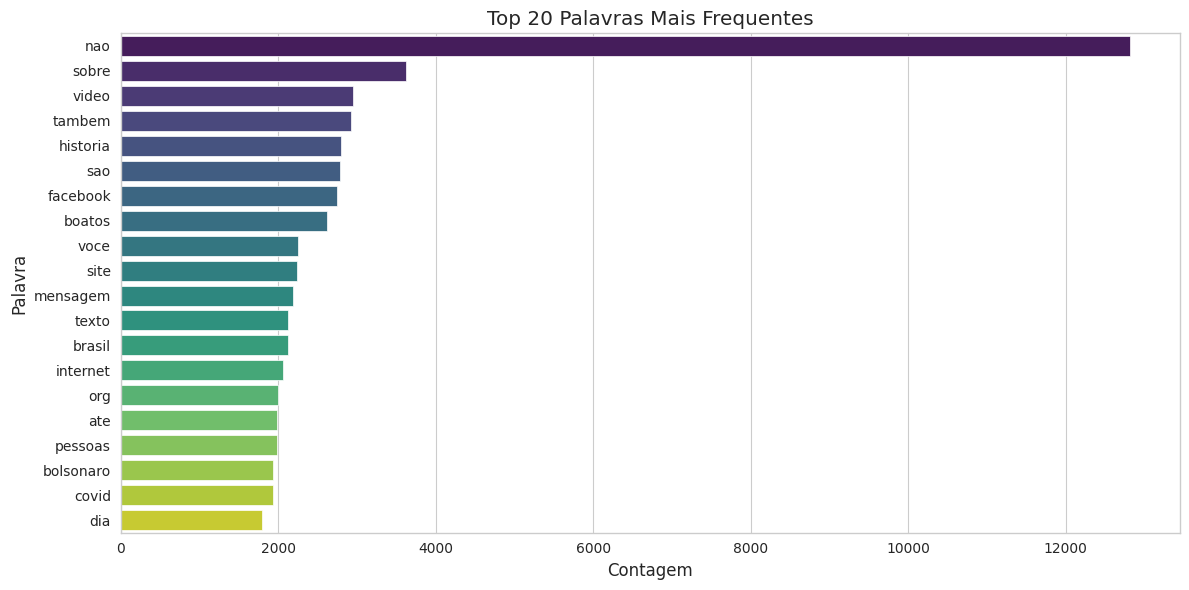

In [ ]:
from collections import Counter

# Juntar todos os textos em uma única string
texto_completo = ' '.join(df_strata['text_news_limpo'])

# Contar frequência de palavras
palavras = texto_completo.split()
contagem_palavras = Counter(palavras)
top_palavras = contagem_palavras.most_common(20)

# Gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(
    x=[count for word, count in top_palavras],
    y=[word for word, count in top_palavras],
    palette='viridis'
)
plt.title('Top 20 Palavras Mais Frequentes')
plt.xlabel('Contagem')
plt.ylabel('Palavra')
plt.tight_layout()
plt.show()

/tmp/ipython-input-63-2749547349.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


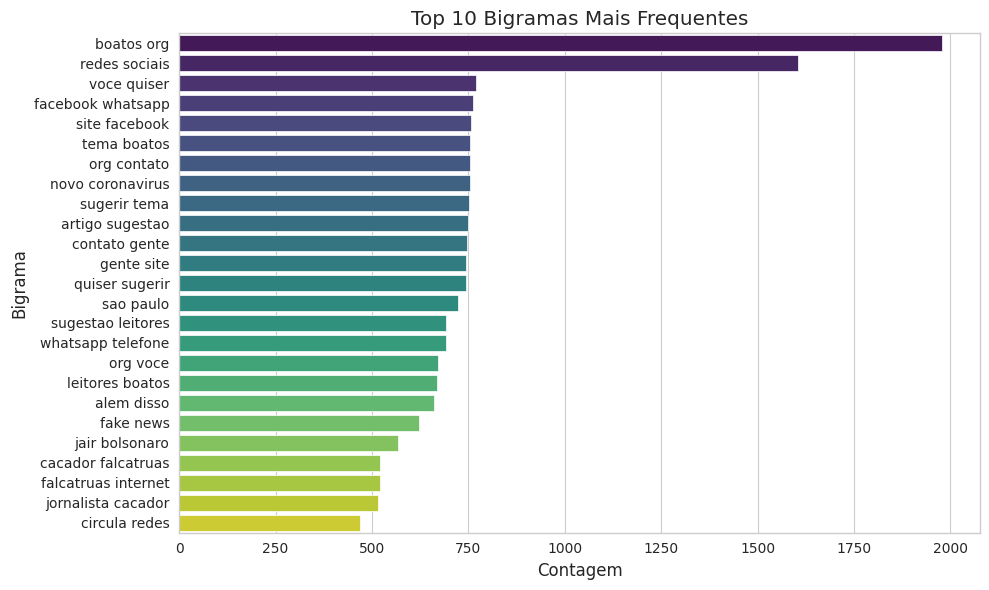

In [ ]:

from nltk import ngrams

# Extrair bigramas (pares de palavras)
bigramas = list(ngrams(palavras, 2))
contagem_bigramas = Counter(bigramas).most_common(25)

# Dataframe para visualização
df_bigramas = pd.DataFrame(contagem_bigramas, columns=['Bigrama', 'Contagem'])
df_bigramas['Bigrama'] = df_bigramas['Bigrama'].apply(lambda x: ' '.join(x))

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_bigramas,
    y='Bigrama',
    x='Contagem',
    palette='viridis'
)
plt.title('Top 10 Bigramas Mais Frequentes')
plt.tight_layout()
plt.show()

In [ ]:
df_bigramas['Bigrama']

,Bigrama
0,boatos org
1,redes sociais
2,voce quiser
3,facebook whatsapp
4,site facebook
5,tema boatos
6,org contato
7,novo coronavirus
8,sugerir tema
9,artigo sugestao


In [ ]:
df_strata

,url,source_name,title,publication_date,text_news,categories,tags,obtained_at,rating,year,rating_escala,month,year_month,title_limpo,text_news_limpo
2145,https://www.boatos.org/brasil/restaurante-gale...,boatos,Restaurante Galeto’s entrou em falência e fech...,2020-05-14,"O isolamento social, mesmo sendo a melhor mane...",[brasil],"[boato, restaurante, galetos, falencia, sp, br...",2021-06-01,['BOATO'],2020,0.0,5,2020-05,restaurante galetos entrou falencia fechou por...,isolamento social sendo melhor maneira deter c...
746,https://g1.globo.com/fato-ou-fake/noticia/2020...,fato-ou-fake,"É #FAKE que nova moeda, chamada DIM, está prog...",2020-07-30,Circula pelas redes sociais um cartaz que diz ...,[desconhecido],desconhecido,2021-05-30,['FAKE'],2020,0.0,7,2020-07,fake nova moeda chamada dim programada entrar ...,circula redes sociais cartaz diz nova moeda br...
959,https://g1.globo.com/fato-ou-fake/noticia/2020...,fato-ou-fake,É #FAKE que Ministério da Saúde orienta parent...,2020-04-02,Uma mensagem com o logotipo do Ministério da S...,[desconhecido],desconhecido,2021-05-30,['FAKE'],2020,0.0,4,2020-04,fake ministerio saude orienta parentes rejeita...,mensagem logotipo ministerio saude criada what...
2629,https://www.boatos.org/tecnologia/boticario-na...,boatos,O Boticário está dando creme Nativa SPA Karité...,2018-10-18,Já falamos aqui que o único tipo de boato não-...,[tecnologia],desconhecido,2021-06-01,['BOATO'],2018,0.0,10,2018-10,boticario dando creme nativa spa karite site w...,falamos aqui unico tipo boato nao relacionado ...
3397,https://www.boatos.org/saude/feijao-esta-com-b...,boatos,Bactéria no feijão vem das plantações; deixe d...,2016-09-06,Em 2015 um dos boatos que mais circularam na i...,[saude],desconhecido,2021-06-01,['BOATO'],2016,0.0,9,2016-09,bacteria feijao vem plantacoes deixe molho vin...,boatos circularam internet feijao bicho nesse ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,https://g1.globo.com/fato-ou-fake/noticia/2020...,fato-ou-fake,É #FAKE que auto-hemoterapia cure a Covid-19,2020-03-24,Circula pelas redes sociais um vídeo em que um...,[desconhecido],desconhecido,2021-05-30,['FAKE'],2020,0.0,3,2020-03,fake auto hemoterapia cure covid,circula redes sociais video homem diz ficou cu...
5147,https://www.aosfatos.org/noticias/nao-ha-proje...,aos fatos,Não há projeto de lei para legalizar a pedofil...,2018-10-15,Circula nas redes sociais uma montagem com uma...,[nas redes],desconhecido,2021-05-30,['FALSO'],2018,0.0,10,2018-10,nao projeto lei legalizar pedofilia imagem dis...,circula redes sociais montagem foto crianca se...
1812,https://www.boatos.org/politica/bolsonaro-cont...,boatos,Bolsonaro descobriu conta secreta de R$ 600 bi...,2020-08-27,"De uns tempos para cá, houve um crescimento ex...",[politica],"[boato, bolsonaro, descobriu, r600bilhdes, bc,...",2021-06-01,['BOATO'],2020,0.0,8,2020-08,bolsonaro descobriu conta secreta bilhoes banc...,tempos crescimento exponencial interesse popul...
3037,https://www.boatos.org/politica/maria-clara-ri...,boatos,Maria Clara Ribeiro Tarabal é procurada pelo a...,2018-09-10,Dentre todos os absurdos que têm surgido após ...,[politica],desconhecido,2021-06-01,['BOATO'],2018,0.0,9,2018-09,maria clara ribeiro tarabal procurada atentado...,dentre todos absurdos surgido apos atentado co...


In [ ]:
df_strata.to_csv('/content/gdrive/MyDrive/base_dados_strata.csv', index=False)


## 3.Bag of Words

`---> ` técnica de processamento de texto que converte documentos em vetores numéricos, contando a frequência de cada palavra em um texto.

In [ ]:
# 1. Reinicie o ambiente (Runtime > Restart runtime) antes de executar!

# 2. Instale as versões compatíveis:
!pip install --upgrade --force-reinstall "numpy<2.0" "gensim==4.3.3" "thinc<8.3.0"

# 3. Verifique se funcionou:
import numpy as np
import gensim


  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached thinc-8.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (15 kB)
  Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached smart_open-7.1.0-py3-none-any.whl.metadata (24 kB)
  Using cached blis-0.7.11-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.4 kB)
  Using cached murmurhash-1.0.13-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.2 kB)
  Using cached cymem-2.0.11-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.5 kB)
  Using cached preshed-3.0.10-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.4 kB)
  Using cached

In [ ]:
import spacy #carregando bibliotecas e funções de limpeza dos textos
!python -m spacy download pt_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 1.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Carrega o modelo de português
nlp = spacy.load("pt_core_news_lg")

def aplicar_lemmatizacao(texto):
    if not isinstance(texto, str):
        return ""

    doc = nlp(texto)
    # Filtra tokens que não são pontuação ou espaços e lematiza
    tokens_lemmas = [token.lemma_ for token in doc if not token.is_punct and not token.is_space]

    return " ".join(tokens_lemmas)



In [ ]:
df_strata['text_news_lemma'] = df_strata['text_news_limpo'].apply(aplicar_lemmatizacao)
df_strata['title_lemma'] = df_strata['title_limpo'].apply(aplicar_lemmatizacao)

# Você pode juntar o texto e título lematizados, se quiser:
df_strata['texto_completo_lemma'] = df_strata['title_lemma'] + " " + df_strata['text_news_lemma']

In [ ]:
df_strata['text_news_lemma']

,text_news_lemma
2145,isolamento social ser bom maneira deter covid ...
746,circular rede social cartaz dizer novo moeda b...
959,mensagem logotipo ministerio saude criar whats...
2629,falar aqui unico tipo boato nao relacionar ele...
3397,boato circular Internet feijao bicho em esse t...
...,...
716,circular rede social video homem dizer ficar c...
5147,circular rede social montagem fotor crianco se...
1812,tempo crescimento exponencial interesse popula...
3037,dentre todo absurdo surgir apos atentado contr...


In [ ]:

standar = ['outro','este','ate','de','fake','ir','sao','ser','tambem','dizer','fazer','caiunarede','falso', 'verificar', 'verificamos', 'boato', 'verifica','fake', 'em','para','estão','que','por']
pdregex = r'\b(?:{})\b'.format('|'.join(map(re.escape,standar)))
df_strata['text_news_lemma_limpo'] = df_strata['text_news_lemma'].str.replace(pdregex, '', regex=True)

In [ ]:
df_strata['title_lemma_limpo'] = df_strata['title_lemma'].str.replace(pdregex, '', regex=True)

In [ ]:
df_strata['texto_completo'] = df_strata['title_lemma_limpo'] + ' ' + df_strata['text_news_lemma_limpo']

In [ ]:
contagem = df_strata['categories'].apply(lambda x: 'desconhecido' in x).value_counts()
print(contagem)

categories
False    1129
True      536
Name: count, dtype: int64


In [ ]:
#df_strata = df_strata.drop(columns=['text_news_lemma', 'title_lemma'])

In [ ]:
df_strata['text_news_lemma_limpo']

,text_news_lemma_limpo
2145,isolamento social bom maneira deter covid tra...
746,circular rede social cartaz novo moeda brasil...
959,mensagem logotipo ministerio saude criar whats...
2629,falar aqui unico tipo nao relacionar eleicoes...
3397,circular Internet feijao bicho esse texto o...
...,...
716,circular rede social video homem ficar curar ...
5147,circular rede social montagem fotor crianco s...
1812,tempo crescimento exponencial interesse popula...
3037,dentre todo absurdo surgir apos atentado contr...


In [ ]:
df_strata

,url,source_name,title,publication_date,text_news,categories,tags,obtained_at,rating,year,...,month,year_month,title_limpo,text_news_limpo,text_news_lemma,title_lemma,texto_completo_lemma,text_news_lemma_limpo,title_lemma_limpo,texto_completo
2145,https://www.boatos.org/brasil/restaurante-gale...,boatos,Restaurante Galeto’s entrou em falência e fech...,2020-05-14,"O isolamento social, mesmo sendo a melhor mane...",[brasil],"[boato, restaurante, galetos, falencia, sp, br...",2021-06-01,['BOATO'],2020,...,5,2020-05,restaurante galetos entrou falencia fechou por...,isolamento social sendo melhor maneira deter c...,isolamento social ser bom maneira deter covid ...,restaurante galeto entrar falencia fechar port...,restaurante galeto entrar falencia fechar port...,isolamento social bom maneira deter covid tra...,restaurante galeto entrar falencia fechar port...,restaurante galeto entrar falencia fechar port...
746,https://g1.globo.com/fato-ou-fake/noticia/2020...,fato-ou-fake,"É #FAKE que nova moeda, chamada DIM, está prog...",2020-07-30,Circula pelas redes sociais um cartaz que diz ...,[desconhecido],desconhecido,2021-05-30,['FAKE'],2020,...,7,2020-07,fake nova moeda chamada dim programada entrar ...,circula redes sociais cartaz diz nova moeda br...,circular rede social cartaz dizer novo moeda b...,Fake novo moeda chamar dim programar entrar vi...,Fake novo moeda chamar dim programar entrar vi...,circular rede social cartaz novo moeda brasil...,Fake novo moeda chamar dim programar entrar vi...,Fake novo moeda chamar dim programar entrar vi...
959,https://g1.globo.com/fato-ou-fake/noticia/2020...,fato-ou-fake,É #FAKE que Ministério da Saúde orienta parent...,2020-04-02,Uma mensagem com o logotipo do Ministério da S...,[desconhecido],desconhecido,2021-05-30,['FAKE'],2020,...,4,2020-04,fake ministerio saude orienta parentes rejeita...,mensagem logotipo ministerio saude criada what...,mensagem logotipo ministerio saude criar whats...,Fake Ministerio saude orientar parente rejeita...,Fake Ministerio saude orientar parente rejeita...,mensagem logotipo ministerio saude criar whats...,Fake Ministerio saude orientar parente rejeita...,Fake Ministerio saude orientar parente rejeita...
2629,https://www.boatos.org/tecnologia/boticario-na...,boatos,O Boticário está dando creme Nativa SPA Karité...,2018-10-18,Já falamos aqui que o único tipo de boato não-...,[tecnologia],desconhecido,2021-06-01,['BOATO'],2018,...,10,2018-10,boticario dando creme nativa spa karite site w...,falamos aqui unico tipo boato nao relacionado ...,falar aqui unico tipo boato nao relacionar ele...,boticario dar creme nativo spa karite site wha...,boticario dar creme nativo spa karite site wha...,falar aqui unico tipo nao relacionar eleicoes...,boticario dar creme nativo spa karite site wha...,boticario dar creme nativo spa karite site wha...
3397,https://www.boatos.org/saude/feijao-esta-com-b...,boatos,Bactéria no feijão vem das plantações; deixe d...,2016-09-06,Em 2015 um dos boatos que mais circularam na i...,[saude],desconhecido,2021-06-01,['BOATO'],2016,...,9,2016-09,bacteria feijao vem plantacoes deixe molho vin...,boatos circularam internet feijao bicho nesse ...,boato circular Internet feijao bicho em esse t...,bacteria feijao vir plantacoes deixar molho vi...,bacteria feijao vir plantacoes deixar molho vi...,circular Internet feijao bicho esse texto o...,bacteria feijao vir plantacoes deixar molho vi...,bacteria feijao vir plantacoes deixar molho vi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,https://g1.globo.com/fato-ou-fake/noticia/2020...,fato-ou-fake,É #FAKE que auto-hemoterapia cure a Covid-19,2020-03-24,Circula pelas redes sociais um vídeo em que um...,[desconhecido],desconhecido,2021-05-30,['FAKE'],2020,...,3,2020-03,fake auto hemoterapia cure covid,circula redes sociais video homem diz ficou cu...,circular rede social video homem dizer ficar c...,Fake auto hemoterapia curar covid,Fake auto hemoterapia cura

In [ ]:
print(sorted(list(stop_words))[:20])


['a', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as', 'até', 'com', 'como', 'da', 'das', 'de', 'dela', 'delas', 'dele', 'deles', 'depois']


In [ ]:
# texto
vectorizer_text = CountVectorizer(max_df=0.95, min_df=2)  # Limite para reduzir dimensionalidade
X_dtm_text = vectorizer_text.fit_transform(df_strata['text_news_lemma_limpo'])

In [ ]:
#titulo
vectorizer_title = CountVectorizer(max_df=0.95, min_df=2)  # Limite para reduzir dimensionalidade

X_dtm_tittle = vectorizer_title.fit_transform(df_strata['title_lemma_limpo'])


In [ ]:
X_dtm_tittle

<1665x1679 sparse matrix of type '<class 'numpy.int64'>'
	with 10424 stored elements in Compressed Sparse Row format>

Tentando o LDA...

TEXTO

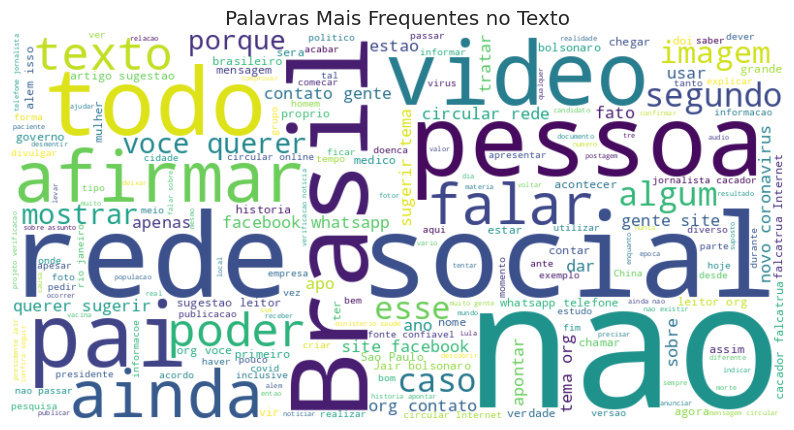

In [ ]:
from wordcloud import WordCloud

# Concatenar todos os títulos (ajuste para sua coluna de texto)
texto = ' '.join(df_strata['text_news_lemma_limpo'].dropna())

# Gerar nuvem de palavras
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(texto)

# Plotar
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palavras Mais Frequentes no Texto')
plt.show()

##Título

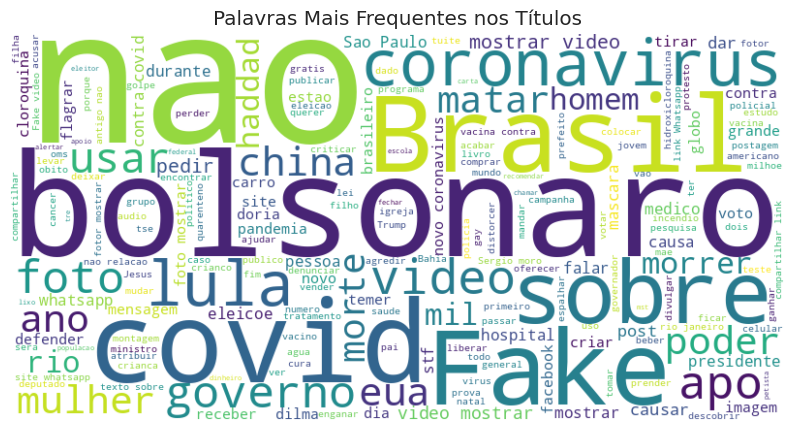

In [ ]:

# Concatenar todos os títulos (ajuste para sua coluna de texto)
texto = ' '.join(df_strata['title_lemma_limpo'].dropna())

# Gerar nuvem de palavras
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(texto)

# Plotar
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palavras Mais Frequentes nos Títulos')
plt.show()

## ///////////////

# NOVA TENTATIVA DE LDA - 10/06

referência: https://www.kaggle.com/code/gauravduttakiit/latent-dirichlet-allocation

Copyright [2021]  [Gaurav Dutta]

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

#Título

In [ ]:
#titulo
vectorizer_title = CountVectorizer(max_features=5000)  # Limite para reduzir dimensionalidade

X_dtm_tittle = vectorizer_title.fit_transform(df_strata['title_lemma_limpo'])


In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
LDA = LatentDirichletAllocation(n_components=12,random_state=42)


In [ ]:
LDA.fit(X_dtm_tittle)

LatentDirichletAllocation(n_components=12, random_state=42)

In [ ]:
len(vectorizer_title.get_feature_names_out())

3897

In [ ]:
import random


In [ ]:
for i in range(10):
    random_word_id = random.randint(0,1686)
    print(vectorizer_title.get_feature_names_out()[random_word_id])

cofr
amazonio
carreta
espirito
criatura
design
andamento
cadaver
crianca
fabio


In [ ]:
for i in range(10):
    random_word_id = random.randint(0,1686)
    print(vectorizer_title.get_feature_names_out()[random_word_id])

abstencoes
chaplin
extremo
agendamento
apertar
engravidar
bebe
foto
advogado
deformar


In [ ]:
len(LDA.components_)


12

In [ ]:
LDA.components_


array([[0.08333333, 1.08333333, 0.08333333, ..., 0.08333333, 0.08333333,
        0.08333333],
       [0.08333333, 0.08333333, 1.08333417, ..., 0.08333333, 0.08333333,
        0.08333333],
       [0.08333333, 0.08333333, 0.08333333, ..., 0.08333333, 0.08333333,
        0.08333333],
       ...,
       [0.08333333, 0.08333333, 0.08333333, ..., 0.08333333, 0.08333333,
        0.08333333],
       [0.08333333, 0.08333333, 0.08333333, ..., 0.08333333, 1.08333333,
        0.08333333],
       [0.08333333, 0.08333333, 0.08333333, ..., 0.08333333, 0.08333333,
        0.08333333]])

In [ ]:
single_topic = LDA.components_[0]


In [ ]:
single_topic.argsort()


array([1866, 2666, 3817, ...,  484, 1633, 2551])

In [ ]:
single_topic[2544]


0.08333333333667824

In [ ]:
single_topic[2511]


2.0833341833221293

In [ ]:
single_topic.argsort()[-10:]


array([1895,  506, 1851, 3045,  196,  937, 2506,  484, 1633, 2551])

In [ ]:
top_word_indices = single_topic.argsort()[-10:]


In [ ]:
for index in top_word_indices:
    print(vectorizer_title.get_feature_names_out()[index])

imagem
brasil
homem
protesto
antigo
covid
mostrar
bolsonaro
foto
nao


In [ ]:
for index,topic in enumerate(LDA.components_):
    print(f'THE TOP 15 WORDS FOR TOPIC #{index}')
    print([vectorizer_title.get_feature_names_out()[i] for i in topic.argsort()[-15:]])
    print('\n')

THE TOP 15 WORDS FOR TOPIC #0
['bispo', 'ano', 'fotor', 'eua', 'adelio', 'imagem', 'brasil', 'homem', 'protesto', 'antigo', 'covid', 'mostrar', 'bolsonaro', 'foto', 'nao']


THE TOP 15 WORDS FOR TOPIC #1
['foto', 'sergio', 'post', 'poder', 'lula', 'denunciar', 'usar', 'ano', 'coronavirus', 'eua', 'video', 'urna', 'eletronico', 'mostrar', 'nao']


THE TOP 15 WORDS FOR TOPIC #2
['site', 'covid', 'mulher', 'coronavirus', 'grupo', 'mil', 'japao', 'durante', 'contra', 'eua', 'bolsonaro', 'voto', 'mostrar', 'nao', 'video']


THE TOP 15 WORDS FOR TOPIC #3
['durante', 'beber', 'argentina', 'mae', 'pessoa', 'basico', 'cesta', 'imagem', 'sobre', 'mil', 'receber', 'pandemia', 'fake', 'post', 'nao']


THE TOP 15 WORDS FOR TOPIC #4
['lula', 'papa', 'policial', 'site', 'bolsonaro', 'fraude', 'circular', 'antigo', 'sobre', 'whatsapp', 'rio', 'mostrar', 'brasil', 'nao', 'video']


THE TOP 15 WORDS FOR TOPIC #5
['mensagem', 'prender', 'golpe', 'vaga', 'covid', 'ministro', 'mulher', 'dia', 'stf', 'site'

In [ ]:
X_dtm_tittle.shape

(1665, 3897)

In [ ]:
len(df_strata)

1665

In [ ]:
topic_results = LDA.transform(X_dtm_tittle)


In [ ]:
topic_results.shape


(1665, 12)

In [ ]:
#PRIMEIRO ARTIGO (linha1), COMO VER:
topic_results[0].round(2)
topic_results[0].argmax()
#isso indica que o lda está no 7

7

In [ ]:
df_strata['title_lemma_limpo'].head()

,title_lemma_limpo
2145,restaurante galeto entrar falencia fechar port...
746,Fake novo moeda chamar dim programar entrar vi...
959,Fake Ministerio saude orientar parente rejeita...
2629,boticario dar creme nativo spa karite site wha...
3397,bacteria feijao vir plantacoes deixar molho vi...


In [ ]:
topic_results.argmax(axis=1)


array([ 7,  6,  2, ...,  8,  7, 11])

In [ ]:
df_strata['titulo_lda'] = topic_results.argmax(axis=1)


In [ ]:
df_strata.head()

,url,source_name,title,publication_date,text_news,categories,tags,obtained_at,rating,year,...,year_month,title_limpo,text_news_limpo,text_news_lemma,title_lemma,texto_completo_lemma,text_news_lemma_limpo,title_lemma_limpo,texto_completo,titulo_lda
2145,https://www.boatos.org/brasil/restaurante-gale...,boatos,Restaurante Galeto’s entrou em falência e fech...,2020-05-14,"O isolamento social, mesmo sendo a melhor mane...",[brasil],"[boato, restaurante, galetos, falencia, sp, br...",2021-06-01,['BOATO'],2020,...,2020-05,restaurante galetos entrou falencia fechou por...,isolamento social sendo melhor maneira deter c...,isolamento social ser bom maneira deter covid ...,restaurante galeto entrar falencia fechar port...,restaurante galeto entrar falencia fechar port...,isolamento social bom maneira deter covid tra...,restaurante galeto entrar falencia fechar port...,restaurante galeto entrar falencia fechar port...,7
746,https://g1.globo.com/fato-ou-fake/noticia/2020...,fato-ou-fake,"É #FAKE que nova moeda, chamada DIM, está prog...",2020-07-30,Circula pelas redes sociais um cartaz que diz ...,[desconhecido],desconhecido,2021-05-30,['FAKE'],2020,...,2020-07,fake nova moeda chamada dim programada entrar ...,circula redes sociais cartaz diz nova moeda br...,circular rede social cartaz dizer novo moeda b...,Fake novo moeda chamar dim programar entrar vi...,Fake novo moeda chamar dim programar entrar vi...,circular rede social cartaz novo moeda brasil...,Fake novo moeda chamar dim programar entrar vi...,Fake novo moeda chamar dim programar entrar vi...,6
959,https://g1.globo.com/fato-ou-fake/noticia/2020...,fato-ou-fake,É #FAKE que Ministério da Saúde orienta parent...,2020-04-02,Uma mensagem com o logotipo do Ministério da S...,[desconhecido],desconhecido,2021-05-30,['FAKE'],2020,...,2020-04,fake ministerio saude orienta parentes rejeita...,mensagem logotipo ministerio saude criada what...,mensagem logotipo ministerio saude criar whats...,Fake Ministerio saude orientar parente rejeita...,Fake Ministerio saude orientar parente rejeita...,mensagem logotipo ministerio saude criar whats...,Fake Ministerio saude orientar parente rejeita...,Fake Ministerio saude orientar parente rejeita...,2
2629,https://www.boatos.org/tecnologia/boticario-na...,boatos,O Boticário está dando creme Nativa SPA Karité...,2018-10-18,Já falamos aqui que o único tipo de boato não-...,[tecnologia],desconhecido,2021-06-01,['BOATO'],2018,...,2018-10,boticario dando creme nativa spa karite site w...,falamos aqui unico tipo boato nao relacionado ...,falar aqui unico tipo boato nao relacionar ele...,boticario dar creme nativo spa karite site wha...,boticario dar creme nativo spa karite site wha...,falar aqui unico tipo nao relacionar eleicoes...,boticario dar creme nativo spa karite site wha...,boticario dar creme nativo spa karite site wha...,0
3397,https://www.boatos.org/saude/feijao-esta-com-b...,boatos,Bactéria no feijão vem das plantações; deixe d...,2016-09-06,Em 2015 um dos boatos que mais circularam na i...,[saude],desconhecido,2021-06-01,['BOATO'],2016,...,2016-09,bacteria feijao vem plantacoes deixe molho vin...,boatos circularam internet feijao bicho nesse ...,boato circular Internet feijao bicho em esse t...,bacteria feijao vir plantacoes deixar molho vi...,bacteria feijao vir plantacoes deixar molho vi...,circular Internet feijao bicho esse texto o...,bacteria feijao vir plantacoes deixar molho vi...,bacteria feijao vir plantacoes deixar molho vi...,6


# TEXT NEWS

In [ ]:
LDA_text = LatentDirichletAllocation(n_components=8,random_state=42)

In [ ]:
LDA_text.fit(X_dtm_text)

LatentDirichletAllocation(n_components=8, random_state=42)

In [ ]:
len(vectorizer_text.get_feature_names_out())


12866

In [ ]:
for i in range(10):
    random_word_id = random.randint(0,12866)
    print(vectorizer_text.get_feature_names_out()[random_word_id])

erguer
indeterminar
instituicoe
corrigir
oms
estampar
ditas
sandoz
puta
ritual


In [ ]:
for i in range(10):
    random_word_id_text = random.randint(0,12874)
    print(vectorizer_text.get_feature_names_out()[random_word_id_text])

iluminacao
permanencia
simbolizar
bicha
caramba
adotar
manuel
vacina
projetar
william


In [ ]:
len(LDA_text.components_)


8

In [ ]:
LDA_text.components_


array([[10.64919821,  0.12521452,  0.125     , ...,  0.12510458,
         0.1469104 ,  0.12516484],
       [ 0.12512603,  0.125     ,  0.12516076, ...,  0.125     ,
         0.125     ,  0.12536571],
       [ 5.90856024,  0.12502662,  0.125     , ...,  0.125     ,
         0.125     ,  0.125     ],
       ...,
       [12.14659705,  2.12472087,  0.12558565, ...,  8.53905593,
         0.12501516,  3.12436925],
       [ 3.22107061,  0.12501153,  4.12299201, ...,  0.125     ,
         0.125     ,  0.12507843],
       [ 0.12517164,  0.125     ,  0.12626158, ...,  0.125     ,
         0.12552328,  0.125     ]])

In [ ]:
len(LDA_text.components_[0])


12866

In [ ]:
single_topic_text = LDA_text.components_[0]
single_topic_text.argsort()


array([9585, 9584, 7024, ..., 5874, 6098,  661])

In [ ]:
# Word least representative of this topic
single_topic_text[1706]


0.12500000172164671

In [ ]:
# Word most representative of this topic
single_topic_text[3221]

0.1253632027364492

In [ ]:
# Top 10 words for this topic:
single_topic_text.argsort()[-10:]

array([ 9252, 10281, 11977,  9398, 12418, 11387, 11914,  5874,  6098,
         661])

In [ ]:
top_word_indices_text = single_topic_text.argsort()[-10:]


In [ ]:
for index in top_word_indices_text:
    print(vectorizer_text.get_feature_names_out()[index])

pessoa
receber
todo
poder
valor
sobre
texto
governo
historia
ano


In [ ]:
for index,topic in enumerate(LDA_text.components_):
    print(f'THE TOP 15 WORDS FOR TOPIC #{index}')
    print([vectorizer_text.get_feature_names_out()[i] for i in topic.argsort()[-20:]])
    print('\n')

THE TOP 15 WORDS FOR TOPIC #0
['ter', 'fato', 'programa', 'mil', 'bolsonaro', 'presidente', 'brasil', 'voce', 'salario', 'site', 'pessoa', 'receber', 'todo', 'poder', 'valor', 'sobre', 'texto', 'governo', 'historia', 'ano']


THE TOP 15 WORDS FOR TOPIC #1
['facebook', 'publicar', 'ministerio', 'bispo', 'adelio', 'projeto', 'dia', 'candidato', 'governo', 'haddad', 'afirmar', 'federal', 'escola', 'video', 'educacao', 'ano', 'presidente', 'sobre', 'lula', 'bolsonaro']


THE TOP 15 WORDS FOR TOPIC #2
['sobre', 'rio', 'pesquisa', 'imagem', 'fato', 'governo', 'presidente', 'mostrar', 'numero', 'eleitoral', 'segundo', 'facebook', 'candidato', 'publicar', 'rede', 'dia', 'social', 'voto', 'video', 'bolsonaro']


THE TOP 15 WORDS FOR TOPIC #3
['processo', 'bolsonaro', 'banco', 'tribunal', 'texto', 'prender', 'federal', 'mensagem', 'sobre', 'juiz', 'brasil', 'poder', 'sergio', 'governo', 'lula', 'lei', 'moro', 'presidente', 'stf', 'ministro']


THE TOP 15 WORDS FOR TOPIC #4
['texto', 'informacao'

In [ ]:
topic_results_text = LDA_text.transform(X_dtm_text)

topic_results_text.argmax(axis=1)
df_strata['texto_lda'] = topic_results_text.argmax(axis=1)


In [ ]:
print(topic_results_text.shape)  # Mostra (n_documentos, n_tópicos)


(1665, 8)


////////////

## ////////////////////////////////////////////

## K-means - título

In [ ]:
topic_results

array([[0.00833378, 0.00833356, 0.0083335 , ..., 0.00833343, 0.00833341,
        0.00833359],
       [0.00833359, 0.00833346, 0.00833353, ..., 0.00833348, 0.00833352,
        0.00833342],
       [0.00694454, 0.00694461, 0.61379936, ..., 0.00694449, 0.00694455,
        0.00694456],
       ...,
       [0.01041738, 0.0104167 , 0.01041691, ..., 0.01041668, 0.01041684,
        0.01041675],
       [0.0092594 , 0.00925927, 0.00925933, ..., 0.00925937, 0.00925932,
        0.00925964],
       [0.14803271, 0.00925929, 0.00925934, ..., 0.00925928, 0.00925927,
        0.7593735 ]])

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
# Definir número de clusters (k) baseado na análise exploratória
kmeans = KMeans(n_clusters=3, random_state=100).fit(topic_results)  # Teste k entre 5-12
df_strata['cluster'] = kmeans.labels_

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7aab5b615da0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error
Exception ignored on calling ctypes callback function: <functio

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
doc_topics_scaled = scaler.fit_transform(topic_results)


In [ ]:
from sklearn.metrics import silhouette_score
print(f"Silhouette Score: {silhouette_score(topic_results, kmeans.labels_):.4f}")

Silhouette Score: 0.2710


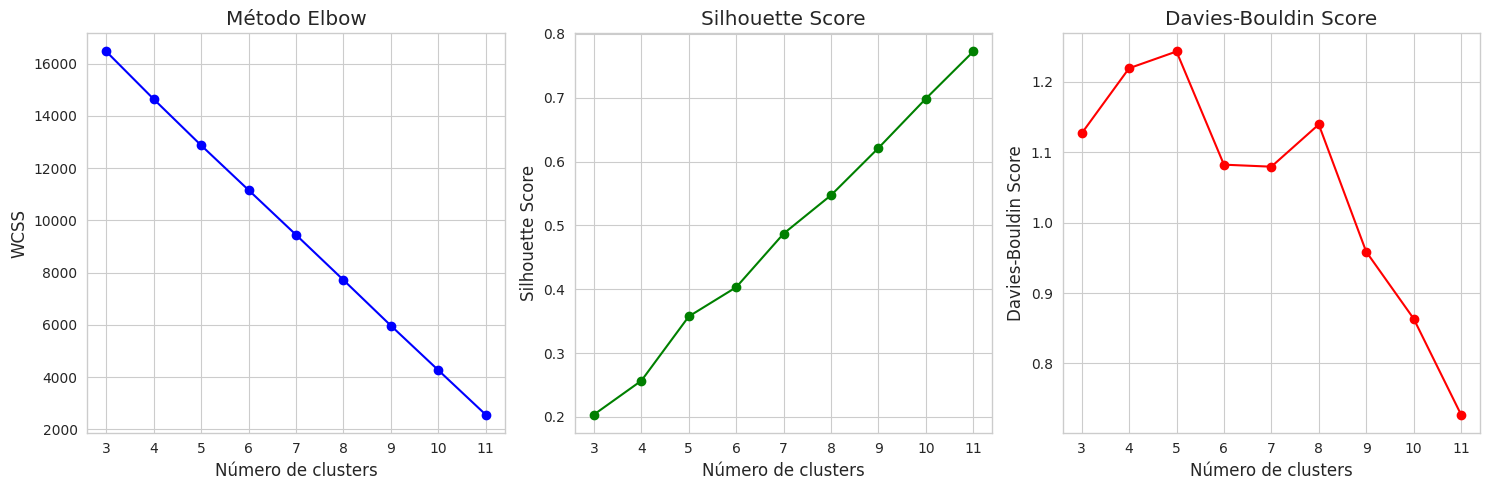


Número ótimo de clusters sugerido: 11


In [ ]:

from sklearn.metrics import silhouette_score, davies_bouldin_score

# 3. Determinar número ótimo de clusters com Elbow Method
wcss = []
silhouette_scores = []
db_scores = []
k_range = range(3, 12)  # Testando de 3 a 11 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=100, n_init=10)
    kmeans.fit(doc_topics_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(doc_topics_scaled, kmeans.labels_))
    db_scores.append(davies_bouldin_score(doc_topics_scaled, kmeans.labels_))

# Plotar gráficos para ajudar na decisão
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(k_range, wcss, 'bo-')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.title('Método Elbow')

plt.subplot(1, 3, 2)
plt.plot(k_range, silhouette_scores, 'go-')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

plt.subplot(1, 3, 3)
plt.plot(k_range, db_scores, 'ro-')
plt.xlabel('Número de clusters')
plt.ylabel('Davies-Bouldin Score')
plt.title('Davies-Bouldin Score')

plt.tight_layout()
plt.show()

# 4. Escolher o melhor k baseado nas métricas (exemplo: máximo silhouette)
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nNúmero ótimo de clusters sugerido: {optimal_k}")



# Kmeans com LDA

In [ ]:
# Definir número de clusters (k) baseado na análise exploratória
kmeans_text = KMeans(n_clusters=4, random_state=100).fit(topic_results_text)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
doc_topics_scaled_text = scaler.fit_transform(topic_results_text)


In [ ]:
df_strata['cluster_text'] = kmeans_text.labels_

In [ ]:
from sklearn.metrics import silhouette_score
print(f"Silhouette Score: {silhouette_score(topic_results_text, kmeans_text.labels_):.4f}")

Silhouette Score: 0.3008


In [ ]:
# Criar DataFrame com as distribuições de tópicos
doc_topics_scaled_text = pd.DataFrame(topic_results_text)

# Calcular a média de cada tópico por cluster
cluster_topic_dist = doc_topics_scaled_text.groupby(df_strata['cluster_text']).mean()

# Mostrar a distribuição completa
print("\nDistribuição média de tópicos por cluster:")
print(cluster_topic_dist.round(3))

# Agora vamos mostrar os tópicos mais relevantes para cada cluster
print("\nTópicos dominantes por cluster:")
for cluster in range(kmeans_text.n_clusters):
    print(f"\nCluster {cluster}:")

    # Pegar os tópicos mais relevantes para este cluster (ordenados por importância)
    sorted_topics = cluster_topic_dist.loc[cluster].sort_values(ascending=False)

    # Mostrar os top 3 tópicos e suas palavras-chave
    for topic_idx, topic_weight in sorted_topics.head(8).items():
        print(f"  Tópico {topic_idx} (peso: {topic_weight:.3f}):")

        # Pegar as palavras mais relevantes para este tópico
        top_words = [vectorizer_title.get_feature_names_out()[i]
                    for i in LDA.components_[topic_idx].argsort()[-10:][::-1]]

        print(f"    Palavras-chave: {', '.join(top_words)}")


Distribuição média de tópicos por cluster:
                  0      1      2      3      4      5      6      7
cluster_text                                                        
0.0           0.092  0.014  0.154  0.061  0.120  0.289  0.176  0.094
1.0           0.075  0.042  0.156  0.047  0.114  0.305  0.149  0.112
2.0           0.059  0.026  0.165  0.046  0.079  0.321  0.194  0.110
3.0           0.136  0.036  0.101  0.044  0.107  0.373  0.077  0.127

Tópicos dominantes por cluster:

Cluster 0:
  Tópico 5 (peso: 0.289):
    Palavras-chave: whatsapp, compartilhar, link, dar, nao, site, stf, dia, mulher, ministro
  Tópico 6 (peso: 0.176):
    Palavras-chave: fake, covid, coronavirus, bolsonaro, morte, contra, novo, sergio, apos, moro
  Tópico 2 (peso: 0.154):
    Palavras-chave: video, nao, mostrar, voto, bolsonaro, eua, contra, durante, japao, mil
  Tópico 4 (peso: 0.120):
    Palavras-chave: video, nao, brasil, mostrar, rio, whatsapp, sobre, antigo, circular, fraude
  Tópico 7 (peso

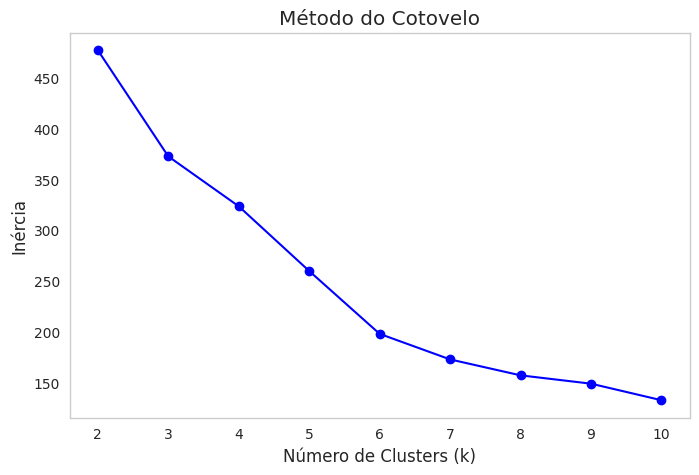

In [ ]:

inertias = []
k_values = range(2, 11)  # Testando de 2 a 10 clusters

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(topic_results_text)
    inertias.append(kmeans.inertia_)

# Plotando o gráfico do cotovelo
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.grid()
plt.show()

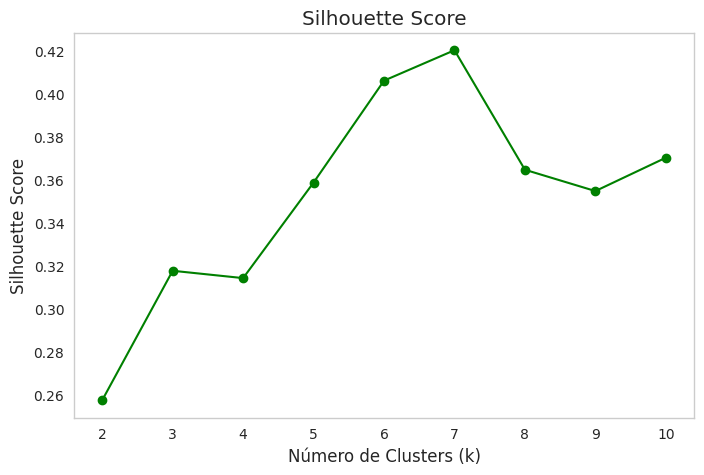

In [ ]:
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(topic_results_text)
    score = silhouette_score(topic_results_text, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, 'go-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.grid()
plt.show()

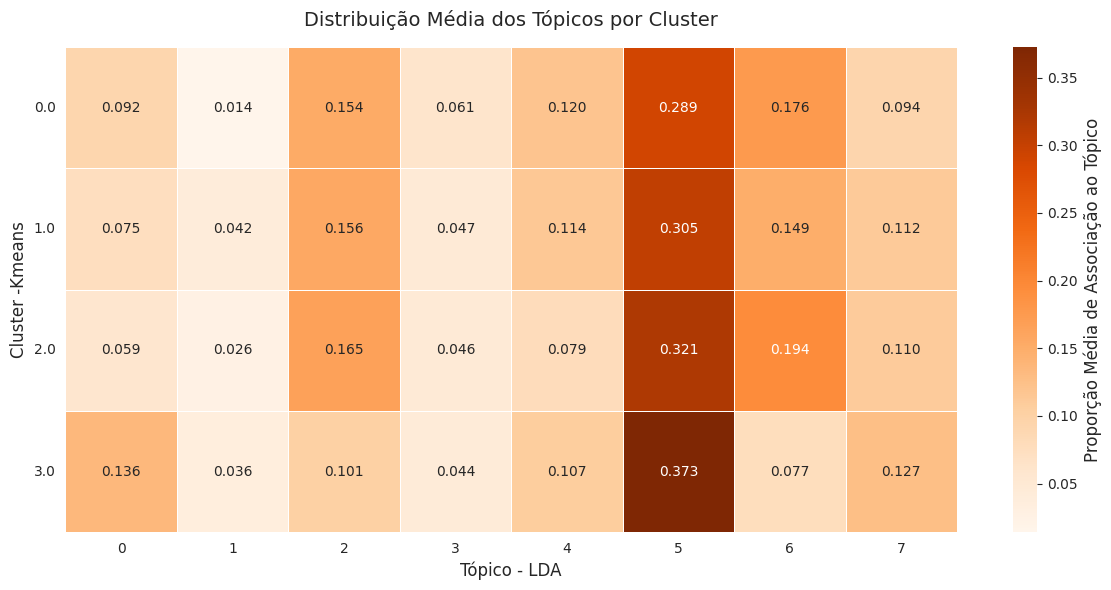

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_topic_dist,
    annot=True,
    fmt=".3f",
    cmap='Oranges',
    linewidths=0.5,
    annot_kws={"size": 10},
    cbar_kws={'label': 'Proporção Média de Associação ao Tópico'}
)
plt.title("Distribuição Média dos Tópicos por Cluster", fontsize=14, pad=15)
plt.xlabel("Tópico - LDA", fontsize=12)
plt.ylabel("Cluster -Kmeans", fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:


print(df_strata.columns)

Index(['url', 'source_name', 'title', 'publication_date', 'text_news',
       'categories', 'tags', 'obtained_at', 'rating', 'year', 'rating_escala',
       'month', 'year_month', 'title_limpo', 'text_news_limpo',
       'text_news_lemma', 'title_lemma', 'texto_completo_lemma',
       'text_news_lemma_limpo', 'title_lemma_limpo', 'texto_completo',
       'titulo_lda', 'texto_lda', 'cluster', 'cluster_text'],
      dtype='object')


In [ ]:
fact_analise = df_strata[['source_name', 'title', 'publication_date', 'text_news', 'categories', 'tags', 'year', 'rating_escala','month', 'year_month', 'titulo_lda', 'texto_lda', 'cluster', 'cluster_text']]

In [ ]:
fact_analise

,source_name,title,publication_date,text_news,categories,tags,year,rating_escala,month,year_month,titulo_lda,texto_lda,cluster,cluster_text
2145,boatos,Restaurante Galeto’s entrou em falência e fech...,2020-05-14,"O isolamento social, mesmo sendo a melhor mane...",[brasil],"[boato, restaurante, galetos, falencia, sp, br...",2020,0.0,5,2020-05,7,5,1,0
746,fato-ou-fake,"É #FAKE que nova moeda, chamada DIM, está prog...",2020-07-30,Circula pelas redes sociais um cartaz que diz ...,[desconhecido],desconhecido,2020,0.0,7,2020-07,6,3,1,1
959,fato-ou-fake,É #FAKE que Ministério da Saúde orienta parent...,2020-04-02,Uma mensagem com o logotipo do Ministério da S...,[desconhecido],desconhecido,2020,0.0,4,2020-04,2,6,1,1
2629,boatos,O Boticário está dando creme Nativa SPA Karité...,2018-10-18,Já falamos aqui que o único tipo de boato não-...,[tecnologia],desconhecido,2018,0.0,10,2018-10,0,5,1,0
3397,boatos,Bactéria no feijão vem das plantações; deixe d...,2016-09-06,Em 2015 um dos boatos que mais circularam na i...,[saude],desconhecido,2016,0.0,9,2016-09,6,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,fato-ou-fake,É #FAKE que auto-hemoterapia cure a Covid-19,2020-03-24,Circula pelas redes sociais um vídeo em que um...,[desconhecido],desconhecido,2020,0.0,3,2020-03,6,6,1,1
5147,aos fatos,Não há projeto de lei para legalizar a pedofil...,2018-10-15,Circula nas redes sociais uma montagem com uma...,[nas redes],desconhecido,2018,0.0,10,2018-10,3,7,1,2
1812,boatos,Bolsonaro descobriu conta secreta de R$ 600 bi...,2020-08-27,"De uns tempos para cá, houve um crescimento ex...",[politica],"[boato, bolsonaro, descobriu, r600bilhdes, bc,...",2020,0.0,8,2020-08,8,5,0,3
3037,boatos,Maria Clara Ribeiro Tarabal é procurada pelo a...,2018-09-10,Dentre todos os absurdos que têm surgido após ...,[politica],desconhecido,2018,0.0,9,2018-09,7,5,1,0


In [ ]:
fact_analise.to_csv('/content/gdrive/MyDrive/fact_analise.csv', index=False)


In [ ]:
fact_analise_test = df_strata[['text_news', 'texto_lda','cluster_text']]

In [ ]:
fact_analise_test .to_csv('/content/gdrive/MyDrive/fact_analise_test.csv', index=False)


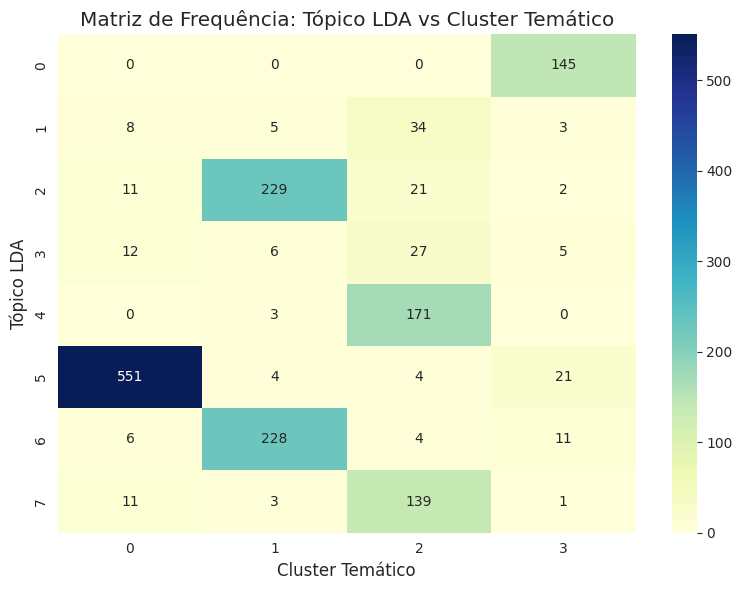

In [ ]:
# Matriz cruzada
pivot_table = pd.crosstab(fact_analise_test['texto_lda'], fact_analise_test['cluster_text'])

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Matriz de Frequência: Tópico LDA vs Cluster Temático')
plt.xlabel('Cluster Temático')
plt.ylabel('Tópico LDA')
plt.tight_layout()
plt.show()


/tmp/ipython-input-150-791468936.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  bubble = sns.scatterplot(


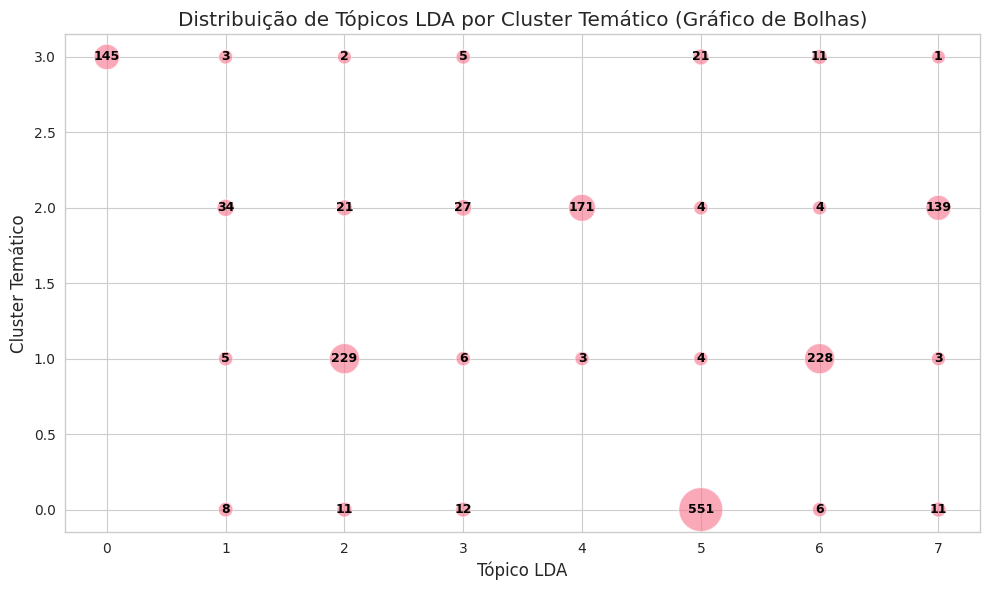

In [ ]:


# Tabela de frequência
df_bolhas = fact_analise_test.groupby(['texto_lda', 'cluster_text']).size().reset_index(name='count')

plt.figure(figsize=(10, 6))
bubble = sns.scatterplot(
    data=df_bolhas,
    x='texto_lda',
    y='cluster_text',
    size='count',
    sizes=(100, 1000),  # controla o tamanho mínimo e máximo das bolhas
    alpha=0.6,
    palette='muted',
    legend=False
)

# Ajustes de rótulos e títulos
plt.title('Distribuição de Tópicos LDA por Cluster Temático (Gráfico de Bolhas)')
plt.xlabel('Tópico LDA')
plt.ylabel('Cluster Temático')
plt.grid(True)
plt.tight_layout()

# Exibir o número de publicações em cada bolha
for i in range(df_bolhas.shape[0]):
    plt.text(
        df_bolhas['texto_lda'][i],
        df_bolhas['cluster_text'][i],
        df_bolhas['count'][i],
        color='black',
        ha='center',
        va='center',
        fontsize=9,
        weight='bold'
    )

plt.show()


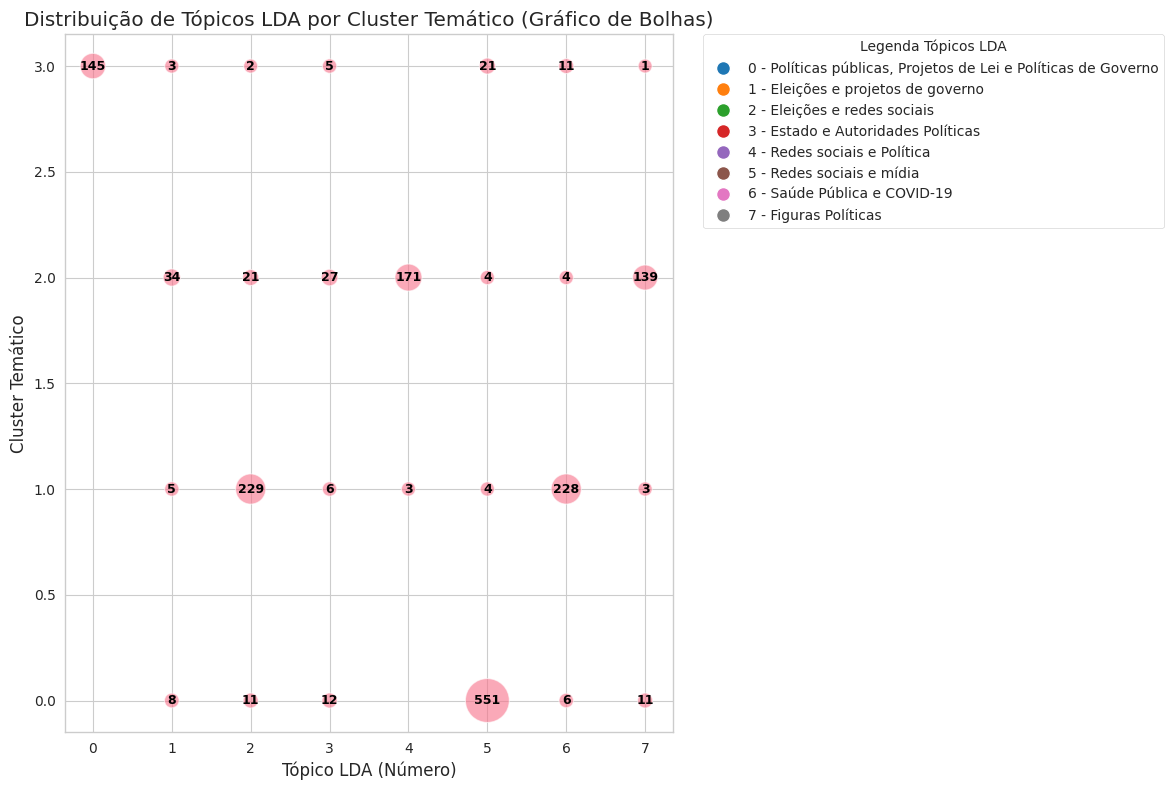

In [ ]:
# Tabela de frequência
df_bolhas = fact_analise_test.groupby(['texto_lda', 'cluster_text']).size().reset_index(name='count')

# Mapeamento dos tópicos LDA para seus rótulos
lda_labels = {
    0: 'Políticas públicas, Projetos de Lei e Políticas de Governo',
    1: 'Eleições e projetos de governo',
    2: 'Eleições e redes sociais',
    3: 'Estado e Autoridades Políticas',
    4: 'Redes sociais e Política',
    5: 'Redes sociais e mídia',
    6: 'Saúde Pública e COVID-19',
    7: 'Figuras Políticas'
}

# Criar o gráfico
plt.figure(figsize=(12, 8))
bubble = sns.scatterplot(
    data=df_bolhas,
    x='texto_lda',
    y='cluster_text',
    size='count',
    sizes=(100, 1000),
    alpha=0.6,
    legend=False
)

# Ajustes de rótulos e títulos
plt.title('Distribuição de Tópicos LDA por Cluster Temático (Gráfico de Bolhas)')
plt.xlabel('Tópico LDA (Número)')
plt.ylabel('Cluster Temático')
plt.grid(True)

# Exibir o número de publicações em cada bolha
for i in range(df_bolhas.shape[0]):
    plt.text(
        df_bolhas['texto_lda'][i],
        df_bolhas['cluster_text'][i],
        df_bolhas['count'][i],
        color='black',
        ha='center',
        va='center',
        fontsize=9,
        weight='bold'
    )

# Criar legenda personalizada para os tópicos LDA
colors = plt.cm.tab10.colors  # Usando a paleta 'tab10' do matplotlib
legend_elements = [plt.Line2D([0], [0],
                   marker='o',
                   color='w',
                   label=f'{num} - {label}',
                   markersize=10,
                   markerfacecolor=colors[i % len(colors)])
                   for i, (num, label) in enumerate(lda_labels.items())]

plt.legend(handles=legend_elements,
           title='Legenda Tópicos LDA',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           borderaxespad=0.)

plt.tight_layout()
plt.show()